# Importer les librairies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time

# Path to MNIST dataset
MNIST_PATH = "./dataset/MNIST"
# Path to Fashion MNIST dataset
FASHION_MNIST_PATH = "./dataset/FASHION_MNIST"

# Charger les datasets MNIST et Fashion MNSIST

In [2]:
def load_mnist_images(filename):
    """
    Load MNIST images from IDX format file.
    Returns images as numpy array of shape (num_images, 28, 28)
    """
    with open(filename, 'rb') as f:
        # Read magic number and dimensions
        magic = struct.unpack('>I', f.read(4))[0]
        num_images = struct.unpack('>I', f.read(4))[0]
        num_rows = struct.unpack('>I', f.read(4))[0]
        num_cols = struct.unpack('>I', f.read(4))[0]
        
        # Read image data
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, num_rows, num_cols)
        return images

def load_mnist_labels(filename):
    """
    Load MNIST labels from IDX format file.
    Returns labels as numpy array of shape (num_labels,)
    """
    with open(filename, 'rb') as f:
        # Read magic number and number of labels
        magic = struct.unpack('>I', f.read(4))[0]
        num_labels = struct.unpack('>I', f.read(4))[0]
        
        # Read label data
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

In [3]:
# Load all MNIST data
print("Loading MNIST dataset...")

# Training data
train_images = load_mnist_images(os.path.join(MNIST_PATH, "train-images.idx3-ubyte"))
train_labels = load_mnist_labels(os.path.join(MNIST_PATH, "train-labels.idx1-ubyte"))

# Test data
test_images = load_mnist_images(os.path.join(MNIST_PATH, "t10k-images.idx3-ubyte"))
test_labels = load_mnist_labels(os.path.join(MNIST_PATH, "t10k-labels.idx1-ubyte"))

print(f"✓ Training data loaded: {train_images.shape} images, {train_labels.shape} labels")
print(f"✓ Test data loaded: {test_images.shape} images, {test_labels.shape} labels")

Loading MNIST dataset...
✓ Training data loaded: (60000, 28, 28) images, (60000,) labels
✓ Test data loaded: (10000, 28, 28) images, (10000,) labels


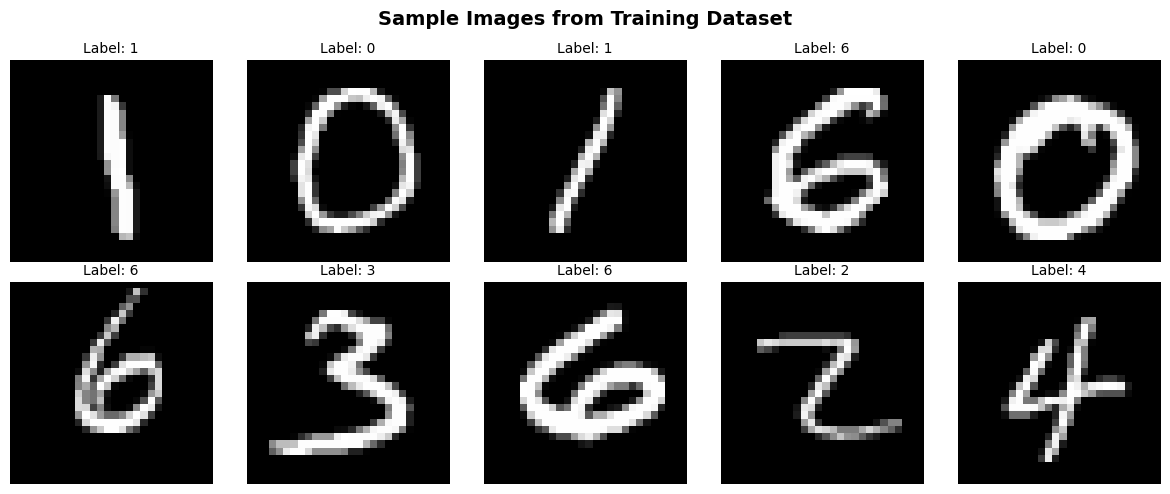

In [4]:
# Display 10 random training images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from Training Dataset", fontsize=14, fontweight='bold')

# Get 10 random indices
random_indices = np.random.choice(len(train_images), 10, replace=False)

for idx, ax in enumerate(axes.flat):
    img_idx = random_indices[idx]
    ax.imshow(train_images[img_idx], cmap='gray')
    ax.set_title(f"Label: {train_labels[img_idx]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Load Fashion MNIST data
print("Loading Fashion MNIST dataset (light version)...")

# Load images and labels
fashion_images = load_mnist_images(os.path.join(FASHION_MNIST_PATH, "images.idx3-ubyte"))
fashion_labels = load_mnist_labels(os.path.join(FASHION_MNIST_PATH, "labels.idx1-ubyte"))

print(f"✓ Dataset loaded: {fashion_images.shape} images, {fashion_labels.shape} labels")

Loading Fashion MNIST dataset (light version)...
✓ Dataset loaded: (1000, 28, 28) images, (1000,) labels


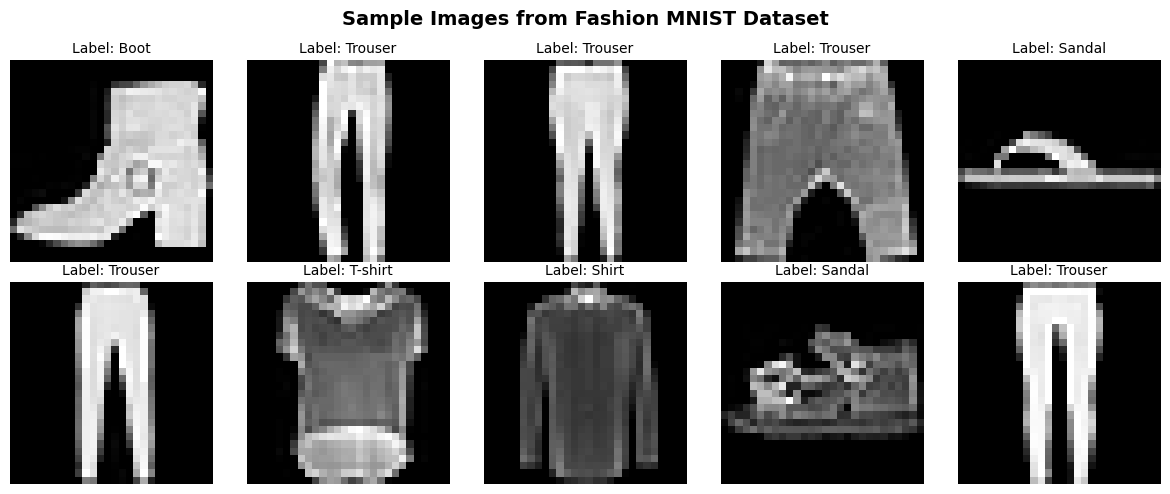

In [6]:
# Display 10 random Fashion MNIST images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images from Fashion MNIST Dataset", fontsize=14, fontweight='bold')

# Fashion MNIST class labels
fashion_class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                       'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

# Get 10 random indices
random_indices = np.random.choice(len(fashion_images), 10, replace=False)

for idx, ax in enumerate(axes.flat):
    img_idx = random_indices[idx]
    ax.imshow(fashion_images[img_idx], cmap='gray')
    ax.set_title(f"Label: {fashion_class_names[fashion_labels[img_idx]]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# MULTI-LAYER PERCEPTRON

In [7]:
# Prepare data: flatten images for MLP
X_train = train_images.reshape(train_images.shape[0], -1)
X_test = test_images.reshape(test_images.shape[0], -1)
y_train = train_labels
y_test = test_labels

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Data prepared for MLP:")
print(f"  - Training data shape: {X_train.shape}")
print(f"  - Test data shape: {X_test.shape}")

Data prepared for MLP:
  - Training data shape: (60000, 784)
  - Test data shape: (10000, 784)


In [8]:
# Define and configure MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64),
    activation='relu',
    max_iter=300,
    batch_size=128,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=0
)

print("\nMLP Configuration:")
print(f"  - Architecture: 784 -> 512 -> 256 -> 128 -> 64 -> 10")
print(f"  - Hidden layers: {mlp.hidden_layer_sizes}")
print(f"  - Activation: {mlp.activation}")
print(f"  - Max iterations: {mlp.max_iter}")
print(f"  - Learning rate: {mlp.learning_rate_init}")
print(f"  - Early stopping: {mlp.early_stopping}")


MLP Configuration:
  - Architecture: 784 -> 512 -> 256 -> 128 -> 64 -> 10
  - Hidden layers: (512, 256, 128, 64)
  - Activation: relu
  - Max iterations: 300
  - Learning rate: 0.001
  - Early stopping: True


In [9]:
# Train model on training data
print("\n" + "="*70)
print("TRAINING MLP ON TRAINING DATA")
print("="*70 + "\n")

print("Training model...")
start_time = time.time()
mlp.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds\n")

# Evaluate on both train and test sets
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

print("TRAINING SET METRICS:")
train_accuracy = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train, average='macro', zero_division=0)
train_recall = recall_score(y_train, y_pred_train, average='macro', zero_division=0)
train_f1 = f1_score(y_train, y_pred_train, average='macro', zero_division=0)

print(f"  - Accuracy:        {train_accuracy:.4f}")
print(f"  - Precision (macro): {train_precision:.4f}")
print(f"  - Recall (macro):    {train_recall:.4f}")
print(f"  - F1-Score (macro):  {train_f1:.4f}")

print("\nTEST SET METRICS:")
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
test_recall = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='macro', zero_division=0)

print(f"  - Accuracy:        {test_accuracy:.4f}")
print(f"  - Precision (macro): {test_precision:.4f}")
print(f"  - Recall (macro):    {test_recall:.4f}")
print(f"  - F1-Score (macro):  {test_f1:.4f}")


TRAINING MLP ON TRAINING DATA

Training model...
Training completed in 125.88 seconds

Training completed in 125.88 seconds

TRAINING SET METRICS:
  - Accuracy:        0.9936
  - Precision (macro): 0.9937
  - Recall (macro):    0.9934
  - F1-Score (macro):  0.9935

TEST SET METRICS:
  - Accuracy:        0.9801
  - Precision (macro): 0.9803
  - Recall (macro):    0.9796
  - F1-Score (macro):  0.9798
TRAINING SET METRICS:
  - Accuracy:        0.9936
  - Precision (macro): 0.9937
  - Recall (macro):    0.9934
  - F1-Score (macro):  0.9935

TEST SET METRICS:
  - Accuracy:        0.9801
  - Precision (macro): 0.9803
  - Recall (macro):    0.9796
  - F1-Score (macro):  0.9798


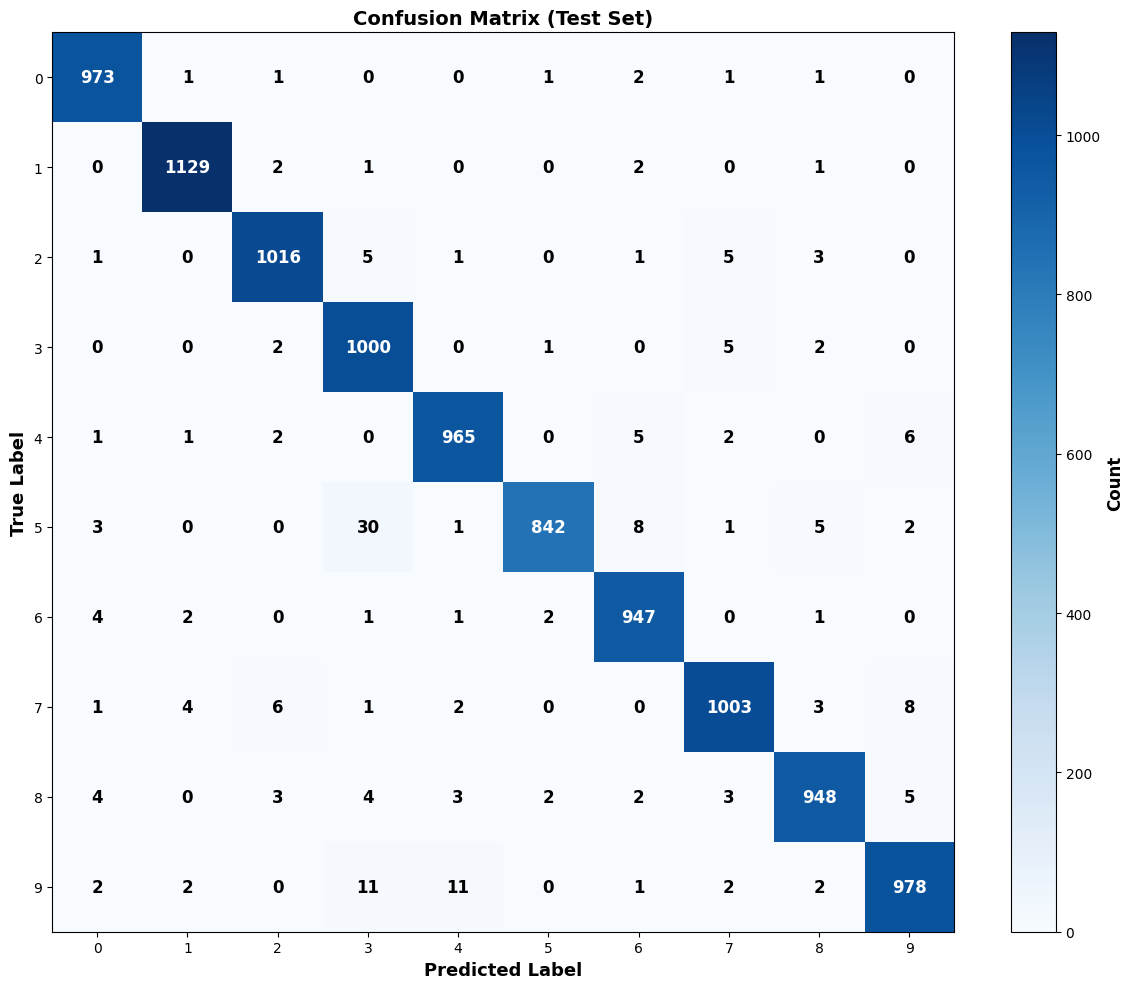

In [10]:
# Visualization of results - Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix with annotations
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))

# Add text annotations showing the counts
for i in range(10):
    for j in range(10):
        count = cm[i, j]
        text_color = 'white' if count > cm.max() / 2 else 'black'
        ax.text(j, i, str(count), ha='center', va='center', color=text_color, fontsize=12, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Prédire les classes avec Random Forest à partir de l'avant dernière couche du MLP

In [11]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Extract features from the second-to-last layer (64 neurons)
# We need to get the activations from the hidden layer before the output layer
# Using MLPClassifier's _forward_pass or by creating a modified predictor

# Method: Use the last hidden layer's activation as features
# The MLP stores coefs_ and intercepts_ for each layer

def get_hidden_layer_activations(model, X, layer_idx=-2):
    """
    Extract activations from a specific hidden layer of the MLP.
    layer_idx=-2 means the second-to-last layer (before output)
    """
    activations = X.copy()
    # Forward pass through all layers except the last one
    for i in range(len(model.coefs_) + layer_idx + 1):
        activations = np.dot(activations, model.coefs_[i]) + model.intercepts_[i]
        # Apply activation function (ReLU for hidden layers)
        if i < len(model.coefs_) + layer_idx:
            activations = np.maximum(activations, 0)  # ReLU activation
    return activations

print("\n" + "="*70)
print("EXTRACTING FEATURES FROM SECOND-TO-LAST LAYER")
print("="*70 + "\n")

# Extract features from training and test sets
print("Extracting 64-dimensional features from second-to-last layer...")
X_train_hidden = get_hidden_layer_activations(mlp, X_train, layer_idx=-2)
X_test_hidden = get_hidden_layer_activations(mlp, X_test, layer_idx=-2)

print(f"✓ Training features shape: {X_train_hidden.shape}")
print(f"✓ Test features shape: {X_test_hidden.shape}")
print(f"✓ Feature dimension: {X_train_hidden.shape[1]} neurons from second-to-last layer")



EXTRACTING FEATURES FROM SECOND-TO-LAST LAYER

Extracting 64-dimensional features from second-to-last layer...
✓ Training features shape: (60000, 64)
✓ Test features shape: (10000, 64)
✓ Feature dimension: 64 neurons from second-to-last layer
✓ Training features shape: (60000, 64)
✓ Test features shape: (10000, 64)
✓ Feature dimension: 64 neurons from second-to-last layer


In [12]:
# Train Random Forest classifier on MLP hidden layer features
print("\n" + "="*70)
print("TRAINING RANDOM FOREST ON HIDDEN LAYER FEATURES")
print("="*70 + "\n")

# Create and configure Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Random Forest Configuration:")
print(f"  - Number of estimators: {rf.n_estimators}")
print(f"  - Max depth: {rf.max_depth}")
print(f"  - Min samples split: {rf.min_samples_split}")
print(f"  - Min samples leaf: {rf.min_samples_leaf}")

# Train the Random Forest
print("\nTraining Random Forest...")
start_time = time.time()
rf.fit(X_train_hidden, y_train)
train_time_rf = time.time() - start_time
print(f"\n✓ Training completed in {train_time_rf:.2f} seconds")

# Make predictions
y_pred_train_rf = rf.predict(X_train_hidden)
y_pred_test_rf = rf.predict(X_test_hidden)

# Evaluate performance
print("\n" + "="*70)
print("RANDOM FOREST PERFORMANCE EVALUATION")
print("="*70)

print("\nTRAINING SET METRICS:")
train_accuracy_rf = accuracy_score(y_train, y_pred_train_rf)
train_precision_rf = precision_score(y_train, y_pred_train_rf, average='macro', zero_division=0)
train_recall_rf = recall_score(y_train, y_pred_train_rf, average='macro', zero_division=0)
train_f1_rf = f1_score(y_train, y_pred_train_rf, average='macro', zero_division=0)

print(f"  - Accuracy:        {train_accuracy_rf:.4f}")
print(f"  - Precision (macro): {train_precision_rf:.4f}")
print(f"  - Recall (macro):    {train_recall_rf:.4f}")
print(f"  - F1-Score (macro):  {train_f1_rf:.4f}")

print("\nTEST SET METRICS:")
test_accuracy_rf = accuracy_score(y_test, y_pred_test_rf)
test_precision_rf = precision_score(y_test, y_pred_test_rf, average='macro', zero_division=0)
test_recall_rf = recall_score(y_test, y_pred_test_rf, average='macro', zero_division=0)
test_f1_rf = f1_score(y_test, y_pred_test_rf, average='macro', zero_division=0)

print(f"  - Accuracy:        {test_accuracy_rf:.4f}")
print(f"  - Precision (macro): {test_precision_rf:.4f}")
print(f"  - Recall (macro):    {test_recall_rf:.4f}")
print(f"  - F1-Score (macro):  {test_f1_rf:.4f}")

# Comparison with MLP
print("\n" + "="*70)
print("COMPARISON: MLP vs Random Forest (on test set)")
print("="*70)
print(f"\nMLP Accuracy:           {test_accuracy:.4f}")
print(f"Random Forest Accuracy: {test_accuracy_rf:.4f}")
print(f"Difference:             {test_accuracy_rf - test_accuracy:+.4f}")



TRAINING RANDOM FOREST ON HIDDEN LAYER FEATURES

Random Forest Configuration:
  - Number of estimators: 100
  - Max depth: 20
  - Min samples split: 5
  - Min samples leaf: 2

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s



✓ Training completed in 7.08 seconds

RANDOM FOREST PERFORMANCE EVALUATION

TRAINING SET METRICS:
  - Accuracy:        0.9990
  - Precision (macro): 0.9990
  - Recall (macro):    0.9990
  - F1-Score (macro):  0.9990

TEST SET METRICS:
  - Accuracy:        0.9823
  - Precision (macro): 0.9822
  - Recall (macro):    0.9820
  - F1-Score (macro):  0.9821

COMPARISON: MLP vs Random Forest (on test set)

MLP Accuracy:           0.9801
Random Forest Accuracy: 0.9823
Difference:             +0.0022


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


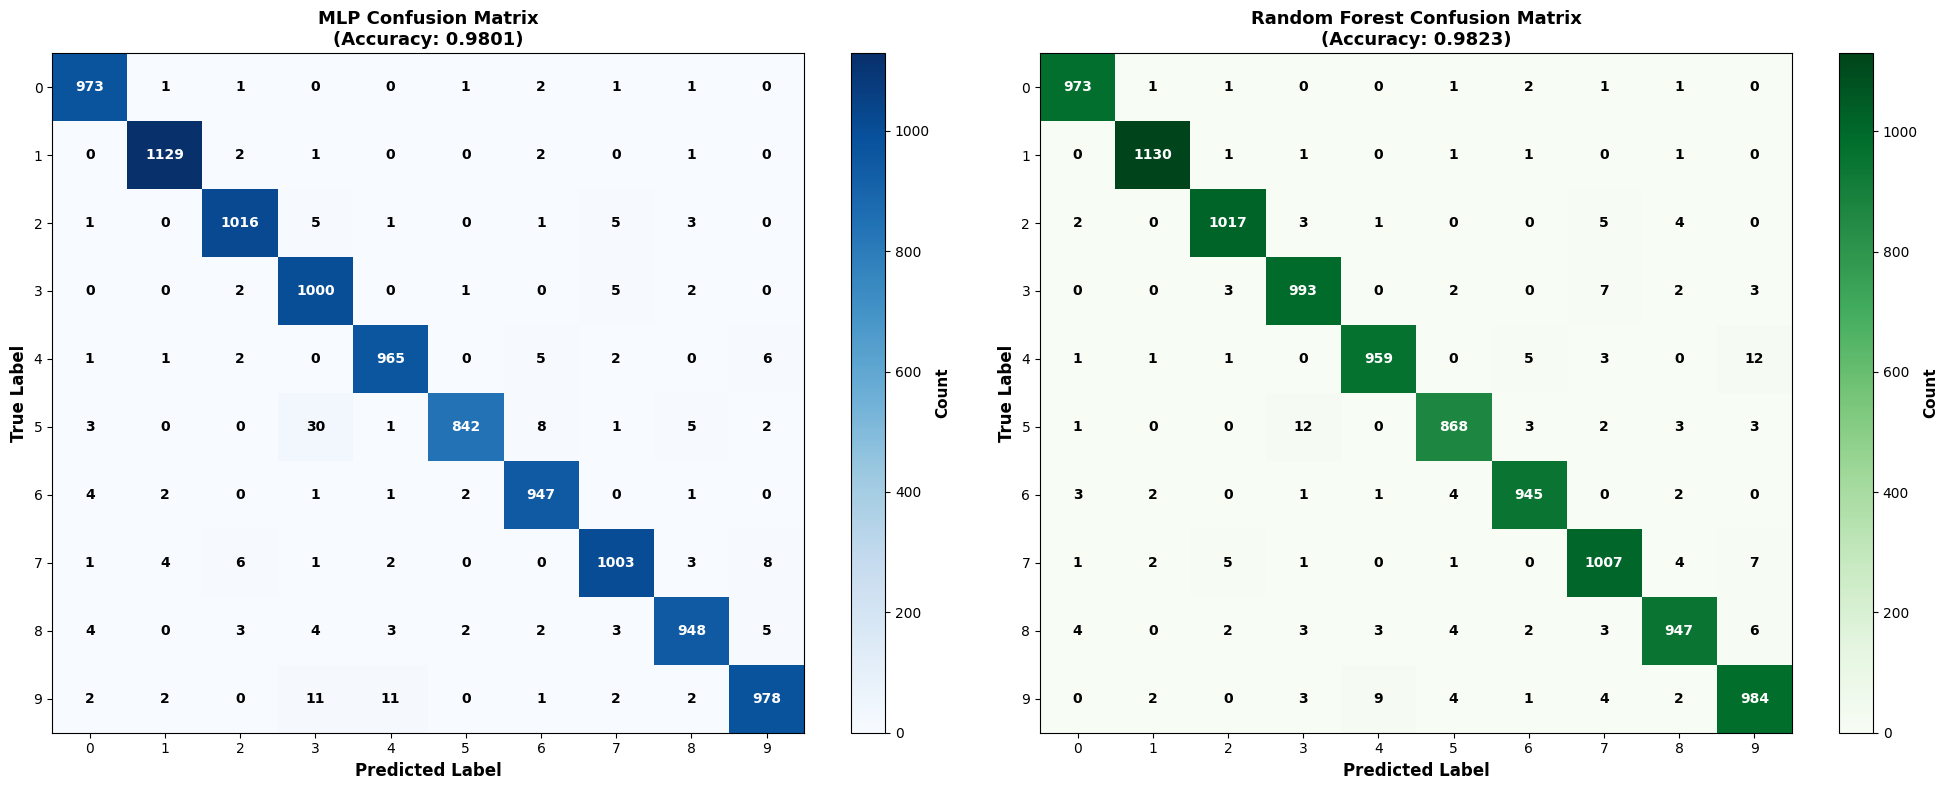

In [13]:
# Visualization - Confusion Matrix for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Compute confusion matrices
cm_mlp = confusion_matrix(y_test, y_pred_test)
cm_rf = confusion_matrix(y_test, y_pred_test_rf)

# Plot MLP confusion matrix
im1 = axes[0].imshow(cm_mlp, cmap='Blues', aspect='auto')
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title(f'MLP Confusion Matrix\n(Accuracy: {test_accuracy:.4f})', fontsize=13, fontweight='bold')
axes[0].set_xticks(np.arange(10))
axes[0].set_yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        count = cm_mlp[i, j]
        text_color = 'white' if count > cm_mlp.max() / 2 else 'black'
        axes[0].text(j, i, str(count), ha='center', va='center', color=text_color, fontsize=10, fontweight='bold')

cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Count', fontsize=11, fontweight='bold')

# Plot Random Forest confusion matrix
im2 = axes[1].imshow(cm_rf, cmap='Greens', aspect='auto')
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title(f'Random Forest Confusion Matrix\n(Accuracy: {test_accuracy_rf:.4f})', fontsize=13, fontweight='bold')
axes[1].set_xticks(np.arange(10))
axes[1].set_yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        count = cm_rf[i, j]
        text_color = 'white' if count > cm_rf.max() / 2 else 'black'
        axes[1].text(j, i, str(count), ha='center', va='center', color=text_color, fontsize=10, fontweight='bold')

cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Count', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## Tester le pipeline sur Fashion MNIST


In [14]:
# Prepare Fashion MNIST data for the pipeline
print("\n" + "="*70)
print("PREPARING FASHION MNIST DATA FOR THE PIPELINE")
print("="*70 + "\n")

# Flatten and normalize Fashion MNIST images
X_fashion = fashion_images.reshape(fashion_images.shape[0], -1) / 255.0
y_fashion = fashion_labels

print(f"Fashion MNIST data shape: {X_fashion.shape}")
print(f"Fashion MNIST labels shape: {y_fashion.shape}")

# Extract hidden layer features for Fashion MNIST using the trained MLP
X_fashion_hidden = get_hidden_layer_activations(mlp, X_fashion, layer_idx=-2)
print(f"Fashion MNIST hidden features shape: {X_fashion_hidden.shape}")

# Make predictions with MLP and Random Forest on Fashion MNIST
y_pred_fashion_mlp = mlp.predict(X_fashion)
y_pred_fashion_rf = rf.predict(X_fashion_hidden)

print(f"\n✓ MLP predictions on Fashion MNIST: {y_pred_fashion_mlp.shape}")
print(f"✓ Random Forest predictions on Fashion MNIST: {y_pred_fashion_rf.shape}")

# Calculate accuracies
fashion_accuracy_mlp = accuracy_score(y_fashion, y_pred_fashion_mlp)
fashion_accuracy_rf = accuracy_score(y_fashion, y_pred_fashion_rf)

print(f"\nFashion MNIST Results:")
print(f"  - MLP Accuracy:           {fashion_accuracy_mlp:.4f}")
print(f"  - Random Forest Accuracy: {fashion_accuracy_rf:.4f}")



PREPARING FASHION MNIST DATA FOR THE PIPELINE

Fashion MNIST data shape: (1000, 784)
Fashion MNIST labels shape: (1000,)
Fashion MNIST hidden features shape: (1000, 64)

✓ MLP predictions on Fashion MNIST: (1000,)
✓ Random Forest predictions on Fashion MNIST: (1000,)

Fashion MNIST Results:
  - MLP Accuracy:           0.1040
  - Random Forest Accuracy: 0.0670


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


In [15]:
# Estimate Epistemic and Aleatoric Uncertainty for Random Forest predictions
print("\n" + "="*70)
print("ESTIMATING EPISTEMIC AND ALEATORIC UNCERTAINTY")
print("="*70 + "\n")

# Get prediction probabilities from Random Forest
from scipy import stats

# Get probability predictions from each tree in the forest
def get_rf_uncertainties(model, X_data):
    """
    Estimate epistemic and aleatoric uncertainty from Random Forest.
    
    Epistemic uncertainty: disagreement between trees (entropy of the ensemble prediction distribution)
                          - Measures model uncertainty: would decrease with more training data
    Aleatoric uncertainty: irreducible uncertainty in the data
                          - We approximate it using the margin (difference between top 2 classes)
    """
    # Get predictions from each tree
    n_trees = model.n_estimators
    predictions = np.array([tree.predict(X_data) for tree in model.estimators_])
    
    # Initialize uncertainties
    epistemic_uncertainty = np.zeros(X_data.shape[0])
    aleatoric_uncertainty = np.zeros(X_data.shape[0])
    
    # Process each sample
    for i in range(X_data.shape[0]):
        # Convert predictions to int to avoid casting issues
        preds_i = predictions[:, i].astype(int)
        
        # Count votes for each class across trees
        votes = np.bincount(preds_i, minlength=10)
        prob_dist = votes / n_trees
        
        # Epistemic uncertainty: entropy of the ensemble vote distribution
        # High when trees strongly disagree on the prediction
        epistemic_uncertainty[i] = -np.sum(prob_dist * np.log(prob_dist + 1e-10))
        
        # Aleatoric uncertainty: measure of confidence in the top prediction
        # Using margin-based approach: distance between top 2 class probabilities
        sorted_probs = np.sort(prob_dist)[::-1]
        margin = sorted_probs[0] - sorted_probs[1]  # Difference between top 2
        aleatoric_uncertainty[i] = 1.0 - margin  # Invert so high margin = low uncertainty
    
    # Ensemble prediction (mode)
    ensemble_pred = np.array([int(np.argmax(np.bincount(predictions[:, i].astype(int), minlength=10))) 
                              for i in range(X_data.shape[0])])
    
    return ensemble_pred, epistemic_uncertainty, aleatoric_uncertainty

# Calculate uncertainties for MNIST test set
y_pred_mnist, epistemic_mnist, aleatoric_mnist = get_rf_uncertainties(rf, X_test_hidden)

# Calculate uncertainties for Fashion MNIST
y_pred_fmnist, epistemic_fmnist, aleatoric_fmnist = get_rf_uncertainties(rf, X_fashion_hidden)

print(f"Epistemic Uncertainty (MNIST):")
print(f"  - Mean: {epistemic_mnist.mean():.6f}")
print(f"  - Std:  {epistemic_mnist.std():.6f}")
print(f"  - Min:  {epistemic_mnist.min():.6f}")
print(f"  - Max:  {epistemic_mnist.max():.6f}")

print(f"\nAleatoric Uncertainty (MNIST):")
print(f"  - Mean: {aleatoric_mnist.mean():.6f}")
print(f"  - Std:  {aleatoric_mnist.std():.6f}")
print(f"  - Min:  {aleatoric_mnist.min():.6f}")
print(f"  - Max:  {aleatoric_mnist.max():.6f}")

print(f"\nEpistemic Uncertainty (Fashion MNIST):")
print(f"  - Mean: {epistemic_fmnist.mean():.6f}")
print(f"  - Std:  {epistemic_fmnist.std():.6f}")
print(f"  - Min:  {epistemic_fmnist.min():.6f}")
print(f"  - Max:  {epistemic_fmnist.max():.6f}")

print(f"\nAleatoric Uncertainty (Fashion MNIST):")
print(f"  - Mean: {aleatoric_fmnist.mean():.6f}")
print(f"  - Std:  {aleatoric_fmnist.std():.6f}")
print(f"  - Min:  {aleatoric_fmnist.min():.6f}")
print(f"  - Max:  {aleatoric_fmnist.max():.6f}")


ESTIMATING EPISTEMIC AND ALEATORIC UNCERTAINTY

Epistemic Uncertainty (MNIST):
  - Mean: 0.063345
  - Std:  0.235545
  - Min:  -0.000000
  - Max:  2.087706

Aleatoric Uncertainty (MNIST):
  - Mean: 0.032076
  - Std:  0.132716
  - Min:  0.000000
  - Max:  1.000000

Epistemic Uncertainty (Fashion MNIST):
  - Mean: 0.939452
  - Std:  0.655973
  - Min:  -0.000000
  - Max:  2.208107

Aleatoric Uncertainty (Fashion MNIST):
  - Mean: 0.462820
  - Std:  0.355302
  - Min:  0.000000
  - Max:  1.000000
Epistemic Uncertainty (MNIST):
  - Mean: 0.063345
  - Std:  0.235545
  - Min:  -0.000000
  - Max:  2.087706

Aleatoric Uncertainty (MNIST):
  - Mean: 0.032076
  - Std:  0.132716
  - Min:  0.000000
  - Max:  1.000000

Epistemic Uncertainty (Fashion MNIST):
  - Mean: 0.939452
  - Std:  0.655973
  - Min:  -0.000000
  - Max:  2.208107

Aleatoric Uncertainty (Fashion MNIST):
  - Mean: 0.462820
  - Std:  0.355302
  - Min:  0.000000
  - Max:  1.000000


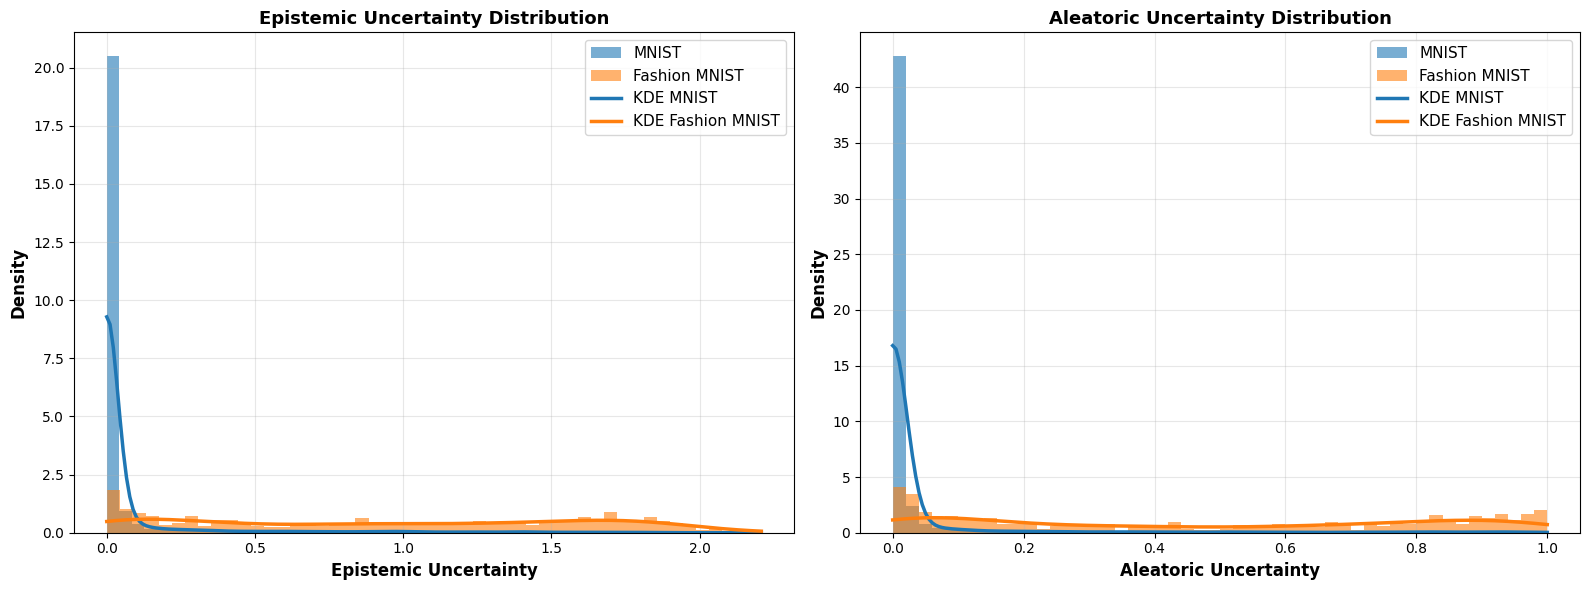

Density plot visualization complete!


In [16]:
from scipy.stats import gaussian_kde

# Create density plots comparing MNIST vs Fashion MNIST uncertainties
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors
color_mnist = '#1f77b4'
color_fmnist = '#ff7f0e'

# Plot 1: Epistemic Uncertainty Distribution
ax = axes[0]
ax.hist(epistemic_mnist, bins=50, alpha=0.6, label='MNIST', color=color_mnist, density=True)
ax.hist(epistemic_fmnist, bins=50, alpha=0.6, label='Fashion MNIST', color=color_fmnist, density=True)

# Add KDE curves
try:
    kde_epi_mnist = gaussian_kde(epistemic_mnist)
    kde_epi_fmnist = gaussian_kde(epistemic_fmnist)
    x_range = np.linspace(min(epistemic_mnist.min(), epistemic_fmnist.min()), 
                          max(epistemic_mnist.max(), epistemic_fmnist.max()), 200)
    ax.plot(x_range, kde_epi_mnist(x_range), color=color_mnist, linewidth=2.5, label='KDE MNIST')
    ax.plot(x_range, kde_epi_fmnist(x_range), color=color_fmnist, linewidth=2.5, label='KDE Fashion MNIST')
except:
    pass

ax.set_xlabel('Epistemic Uncertainty', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Epistemic Uncertainty Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Aleatoric Uncertainty Distribution
ax = axes[1]
ax.hist(aleatoric_mnist, bins=50, alpha=0.6, label='MNIST', color=color_mnist, density=True)
ax.hist(aleatoric_fmnist, bins=50, alpha=0.6, label='Fashion MNIST', color=color_fmnist, density=True)

# Add KDE curves
try:
    kde_ale_mnist = gaussian_kde(aleatoric_mnist)
    kde_ale_fmnist = gaussian_kde(aleatoric_fmnist)
    x_range = np.linspace(min(aleatoric_mnist.min(), aleatoric_fmnist.min()), 
                          max(aleatoric_mnist.max(), aleatoric_fmnist.max()), 200)
    ax.plot(x_range, kde_ale_mnist(x_range), color=color_mnist, linewidth=2.5, label='KDE MNIST')
    ax.plot(x_range, kde_ale_fmnist(x_range), color=color_fmnist, linewidth=2.5, label='KDE Fashion MNIST')
except:
    pass

ax.set_xlabel('Aleatoric Uncertainty', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Aleatoric Uncertainty Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Density plot visualization complete!")


2D UNCERTAINTY SPACE VISUALIZATION

MNIST samples: 1000
Fashion MNIST samples: 1000


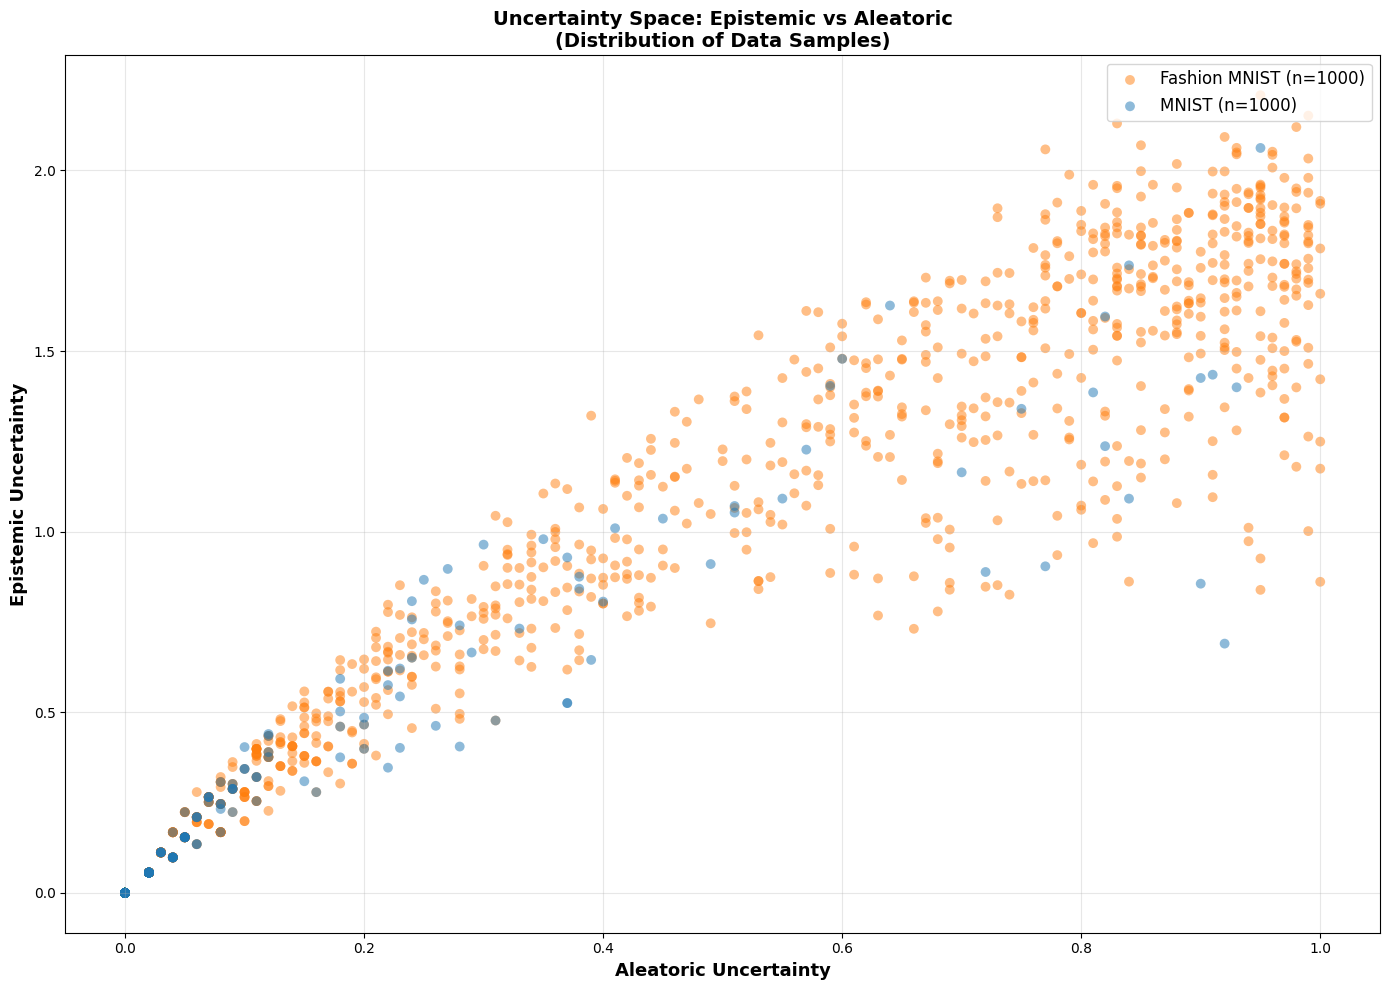


MNIST Sample Statistics:
  Aleatoric - Mean: 0.031230, Std: 0.124378
  Epistemic - Mean: 0.065296, Std: 0.233256

Fashion MNIST Sample Statistics:
  Aleatoric - Mean: 0.462820, Std: 0.355302
  Epistemic - Mean: 0.939452, Std: 0.655973

Center separation distance: 0.974894


In [17]:
# 2D Uncertainty Space: Aleatoric vs Epistemic
print("\n" + "="*70)
print("2D UNCERTAINTY SPACE VISUALIZATION")
print("="*70 + "\n")

# Select 1000 random samples from MNIST test set
mnist_sample_size = min(1000, len(epistemic_mnist))
mnist_indices = np.random.choice(len(epistemic_mnist), mnist_sample_size, replace=False)
epistemic_mnist_sample = epistemic_mnist[mnist_indices]
aleatoric_mnist_sample = aleatoric_mnist[mnist_indices]

# Use up to 1000 Fashion MNIST samples
fmnist_sample_size = min(1000, len(epistemic_fmnist))
epistemic_fmnist_sample = epistemic_fmnist[:fmnist_sample_size]
aleatoric_fmnist_sample = aleatoric_fmnist[:fmnist_sample_size]

print(f"MNIST samples: {mnist_sample_size}")
print(f"Fashion MNIST samples: {fmnist_sample_size}")

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot Fashion MNIST (red/orange points)
scatter1 = ax.scatter(aleatoric_fmnist_sample, epistemic_fmnist_sample, 
                      alpha=0.5, s=50, color='#ff7f0e', label=f'Fashion MNIST (n={fmnist_sample_size})',
                      edgecolors='none')

# Plot MNIST (blue points)
scatter2 = ax.scatter(aleatoric_mnist_sample, epistemic_mnist_sample, 
                      alpha=0.5, s=50, color='#1f77b4', label=f'MNIST (n={mnist_sample_size})',
                      edgecolors='none')

ax.set_xlabel('Aleatoric Uncertainty', fontsize=13, fontweight='bold')
ax.set_ylabel('Epistemic Uncertainty', fontsize=13, fontweight='bold')
ax.set_title('Uncertainty Space: Epistemic vs Aleatoric\n(Distribution of Data Samples)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for the 2D space
print("\nMNIST Sample Statistics:")
print(f"  Aleatoric - Mean: {aleatoric_mnist_sample.mean():.6f}, Std: {aleatoric_mnist_sample.std():.6f}")
print(f"  Epistemic - Mean: {epistemic_mnist_sample.mean():.6f}, Std: {epistemic_mnist_sample.std():.6f}")

print("\nFashion MNIST Sample Statistics:")
print(f"  Aleatoric - Mean: {aleatoric_fmnist_sample.mean():.6f}, Std: {aleatoric_fmnist_sample.std():.6f}")
print(f"  Epistemic - Mean: {epistemic_fmnist_sample.mean():.6f}, Std: {epistemic_fmnist_sample.std():.6f}")

# Calculate separation in 2D space
mnist_center = np.array([aleatoric_mnist_sample.mean(), epistemic_mnist_sample.mean()])
fmnist_center = np.array([aleatoric_fmnist_sample.mean(), epistemic_fmnist_sample.mean()])
separation_distance = np.linalg.norm(fmnist_center - mnist_center)

print(f"\nCenter separation distance: {separation_distance:.6f}")

In [18]:
# Statistical comparison between MNIST and Fashion MNIST uncertainties
from scipy.stats import mannwhitneyu, ks_2samp

print("\n" + "="*70)
print("STATISTICAL COMPARISON: MNIST vs Fashion MNIST")
print("="*70)

# Epistemic Uncertainty Comparison
print("\nEpistemic Uncertainty:")
stat_epi, p_value_epi = mannwhitneyu(epistemic_mnist, epistemic_fmnist, alternative='two-sided')
print(f"  Mann-Whitney U test p-value: {p_value_epi:.2e}")
print(f"  Significant difference: {'Yes' if p_value_epi < 0.05 else 'No'}")
print(f"  Mean difference: {epistemic_fmnist.mean() - epistemic_mnist.mean():.6f}")
print(f"  Median difference: {np.median(epistemic_fmnist) - np.median(epistemic_mnist):.6f}")

# Aleatoric Uncertainty Comparison
print("\nAleatoric Uncertainty:")
stat_ale, p_value_ale = mannwhitneyu(aleatoric_mnist, aleatoric_fmnist, alternative='two-sided')
print(f"  Mann-Whitney U test p-value: {p_value_ale:.2e}")
print(f"  Significant difference: {'Yes' if p_value_ale < 0.05 else 'No'}")
print(f"  Mean difference: {aleatoric_fmnist.mean() - aleatoric_mnist.mean():.6f}")
print(f"  Median difference: {np.median(aleatoric_fmnist) - np.median(aleatoric_mnist):.6f}")

# Calculate percentiles
print("\n" + "="*70)
print("UNCERTAINTY PERCENTILES")
print("="*70)

print("\nEpistemic Uncertainty Percentiles:")
print(f"  MNIST - 25th: {np.percentile(epistemic_mnist, 25):.6f}, " +
      f"50th: {np.percentile(epistemic_mnist, 50):.6f}, " +
      f"75th: {np.percentile(epistemic_mnist, 75):.6f}")
print(f"  Fashion MNIST - 25th: {np.percentile(epistemic_fmnist, 25):.6f}, " +
      f"50th: {np.percentile(epistemic_fmnist, 50):.6f}, " +
      f"75th: {np.percentile(epistemic_fmnist, 75):.6f}")

print("\nAleatoric Uncertainty Percentiles:")
print(f"  MNIST - 25th: {np.percentile(aleatoric_mnist, 25):.6f}, " +
      f"50th: {np.percentile(aleatoric_mnist, 50):.6f}, " +
      f"75th: {np.percentile(aleatoric_mnist, 75):.6f}")
print(f"  Fashion MNIST - 25th: {np.percentile(aleatoric_fmnist, 25):.6f}, " +
      f"50th: {np.percentile(aleatoric_fmnist, 50):.6f}, " +
      f"75th: {np.percentile(aleatoric_fmnist, 75):.6f}")



STATISTICAL COMPARISON: MNIST vs Fashion MNIST

Epistemic Uncertainty:
  Mann-Whitney U test p-value: 0.00e+00
  Significant difference: Yes
  Mean difference: 0.876107
  Median difference: 0.939972

Aleatoric Uncertainty:
  Mann-Whitney U test p-value: 0.00e+00
  Significant difference: Yes
  Mean difference: 0.430744
  Median difference: 0.430000

UNCERTAINTY PERCENTILES

Epistemic Uncertainty Percentiles:
  MNIST - 25th: -0.000000, 50th: -0.000000, 75th: -0.000000
  Fashion MNIST - 25th: 0.287652, 50th: 0.939972, 75th: 1.556195

Aleatoric Uncertainty Percentiles:
  MNIST - 25th: 0.000000, 50th: 0.000000, 75th: 0.000000
  Fashion MNIST - 25th: 0.100000, 50th: 0.430000, 75th: 0.820000



MNIST SAMPLES WITH HIGHEST CUMULATIVE UNCERTAINTY

Top 10 MNIST samples with highest cumulative uncertainty:

Rank   Index    True Label   Pred Label   Epistemic    Aleatoric    Cumulative  
------------------------------------------------------------------------------------------
1      1941     7            8            2.073606     1.000000     0.996623     ✗
2      3060     9            9            2.087706     0.940000     0.970000     ✓
3      4163     9            5            2.062129     0.950000     0.968875     ✗
4      2293     9            6            1.828259     0.990000     0.932863     ✗
5      2422     6            6            1.784033     0.980000     0.917271     ✓
6      5888     4            4            1.825426     0.950000     0.912185     ✓
7      9679     6            3            1.871315     0.920000     0.908175     ✗
8      5676     4            7            1.866393     0.920000     0.906996     ✗
9      4176     2            7            1.732652   

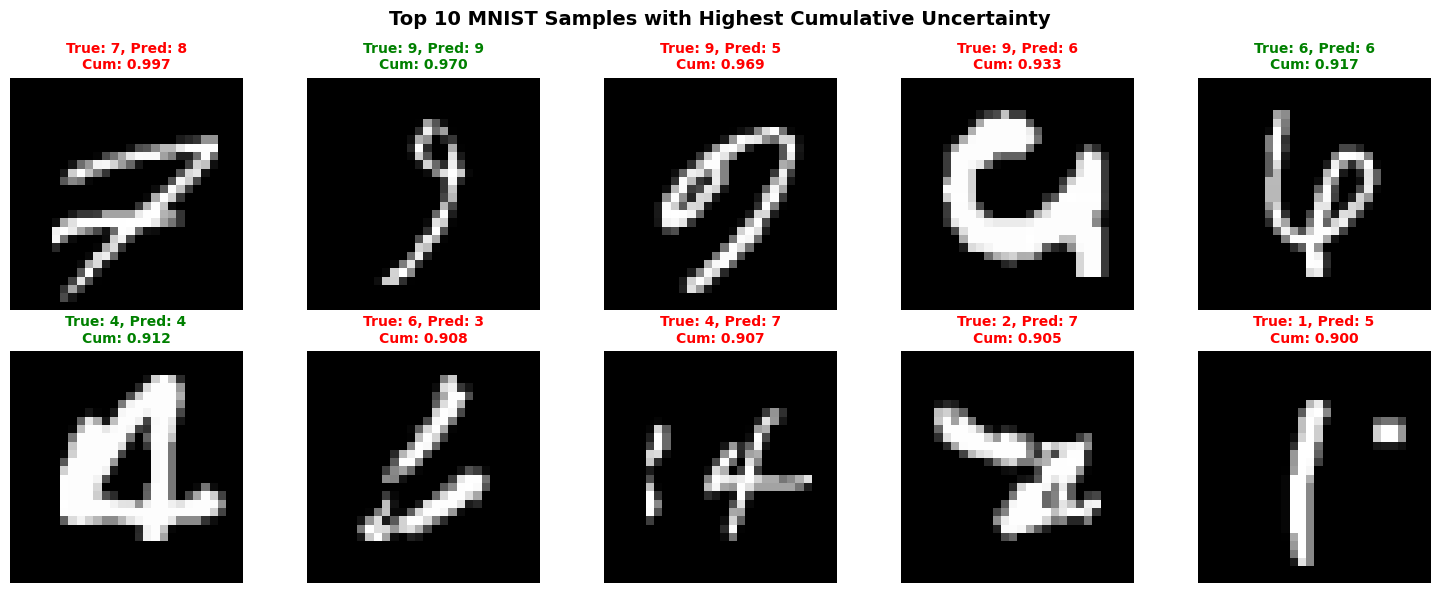


Visualization complete!
Green titles = Correct predictions, Red titles = Incorrect predictions


In [19]:
# Analyze MNIST samples with highest cumulative uncertainty
print("\n" + "="*70)
print("MNIST SAMPLES WITH HIGHEST CUMULATIVE UNCERTAINTY")
print("="*70 + "\n")

# Calculate cumulative uncertainty (normalized sum of both uncertainties)
# Normalize both to [0, 1] range first for fair comparison
epi_min, epi_max = epistemic_mnist.min(), epistemic_mnist.max()
ale_min, ale_max = aleatoric_mnist.min(), aleatoric_mnist.max()

epistemic_norm = (epistemic_mnist - epi_min) / (epi_max - epi_min + 1e-10)
aleatoric_norm = (aleatoric_mnist - ale_min) / (ale_max - ale_min + 1e-10)

# Cumulative uncertainty: equal weight to both
cumulative_uncertainty = 0.5 * epistemic_norm + 0.5 * aleatoric_norm

# Find top 10 indices with highest cumulative uncertainty
worst_indices = np.argsort(cumulative_uncertainty)[-10:][::-1]

print("Top 10 MNIST samples with highest cumulative uncertainty:\n")
print(f"{'Rank':<6} {'Index':<8} {'True Label':<12} {'Pred Label':<12} {'Epistemic':<12} {'Aleatoric':<12} {'Cumulative':<12}")
print("-" * 90)

for rank, idx in enumerate(worst_indices, 1):
    true_label = y_test[idx]
    pred_label = y_pred_test_rf[idx]
    correct = "✓" if true_label == pred_label else "✗"
    epi = epistemic_mnist[idx]
    ale = aleatoric_mnist[idx]
    cum = cumulative_uncertainty[idx]
    
    print(f"{rank:<6} {idx:<8} {true_label:<12} {pred_label:<12} {epi:<12.6f} {ale:<12.6f} {cum:<12.6f} {correct}")

# Display the 10 worst images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Top 10 MNIST Samples with Highest Cumulative Uncertainty', fontsize=14, fontweight='bold')

for i, idx in enumerate(worst_indices):
    ax = axes[i // 5, i % 5]
    
    # Get the image from test set
    img = test_images[idx]
    
    ax.imshow(img, cmap='gray')
    
    true_label = y_test[idx]
    pred_label = y_pred_test_rf[idx]
    correct = true_label == pred_label
    
    # Color the title based on correctness
    title_color = 'green' if correct else 'red'
    
    epi = epistemic_mnist[idx]
    ale = aleatoric_mnist[idx]
    cum = cumulative_uncertainty[idx]
    
    title = f"True: {true_label}, Pred: {pred_label}\n"
    title += f"Cum: {cum:.3f}"
    
    ax.set_title(title, fontsize=10, fontweight='bold', color=title_color)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")
print(f"Green titles = Correct predictions, Red titles = Incorrect predictions")

## Anomaly Detection avec seuil d'Incertitude

In [20]:
# Calculate anomaly threshold based on cumulative uncertainty
print("\n" + "="*70)
print("ANOMALY DETECTION THRESHOLD CALCULATION")
print("="*70 + "\n")

# We want 5% of MNIST samples to be classified as anomalies
# Find the 95th percentile of cumulative uncertainty
anomaly_threshold_percentile = 95
anomaly_threshold = np.percentile(cumulative_uncertainty, anomaly_threshold_percentile)

print(f"Anomaly Detection Configuration:")
print(f"  - Percentile used: {anomaly_threshold_percentile}%")
print(f"  - Cumulative uncertainty threshold: {anomaly_threshold:.6f}")

# Count how many MNIST samples are above the threshold
n_anomalies_mnist = np.sum(cumulative_uncertainty >= anomaly_threshold)
pct_anomalies_mnist = 100 * n_anomalies_mnist / len(cumulative_uncertainty)

print(f"\nMNIST Test Set Results:")
print(f"  - Total samples: {len(cumulative_uncertainty)}")
print(f"  - Samples above threshold: {n_anomalies_mnist}")
print(f"  - Percentage: {pct_anomalies_mnist:.2f}%")

# Apply to Fashion MNIST
n_anomalies_fmnist = np.sum((0.5 * epistemic_fmnist + 0.5 * aleatoric_fmnist) >= anomaly_threshold)
pct_anomalies_fmnist = 100 * n_anomalies_fmnist / len(epistemic_fmnist)

print(f"\nFashion MNIST Results:")
print(f"  - Total samples: {len(epistemic_fmnist)}")
print(f"  - Samples classified as anomalies: {n_anomalies_fmnist}")
print(f"  - Percentage: {pct_anomalies_fmnist:.2f}%")

# Create predictions with anomaly class (10 = anomaly)
y_pred_with_anomaly_mnist = np.copy(y_pred_test_rf).astype(int)
y_pred_with_anomaly_mnist[cumulative_uncertainty >= anomaly_threshold] = 10

y_pred_with_anomaly_fmnist = np.copy(y_pred_fashion_rf).astype(int)
fmnist_cumulative = 0.5 * epistemic_fmnist + 0.5 * aleatoric_fmnist
y_pred_with_anomaly_fmnist[fmnist_cumulative >= anomaly_threshold] = 10

print(f"\nPredictions with anomaly class created (class 10 = anomaly)")
print(f"MNIST with anomaly predictions: {y_pred_with_anomaly_mnist.shape}")
print(f"Fashion MNIST with anomaly predictions: {y_pred_with_anomaly_fmnist.shape}")


ANOMALY DETECTION THRESHOLD CALCULATION

Anomaly Detection Configuration:
  - Percentile used: 95%
  - Cumulative uncertainty threshold: 0.194644

MNIST Test Set Results:
  - Total samples: 10000
  - Samples above threshold: 500
  - Percentage: 5.00%

Fashion MNIST Results:
  - Total samples: 1000
  - Samples classified as anomalies: 747
  - Percentage: 74.70%

Predictions with anomaly class created (class 10 = anomaly)
MNIST with anomaly predictions: (10000,)
Fashion MNIST with anomaly predictions: (1000,)



ANOMALY DETECTION BOUNDARY VISUALIZATION



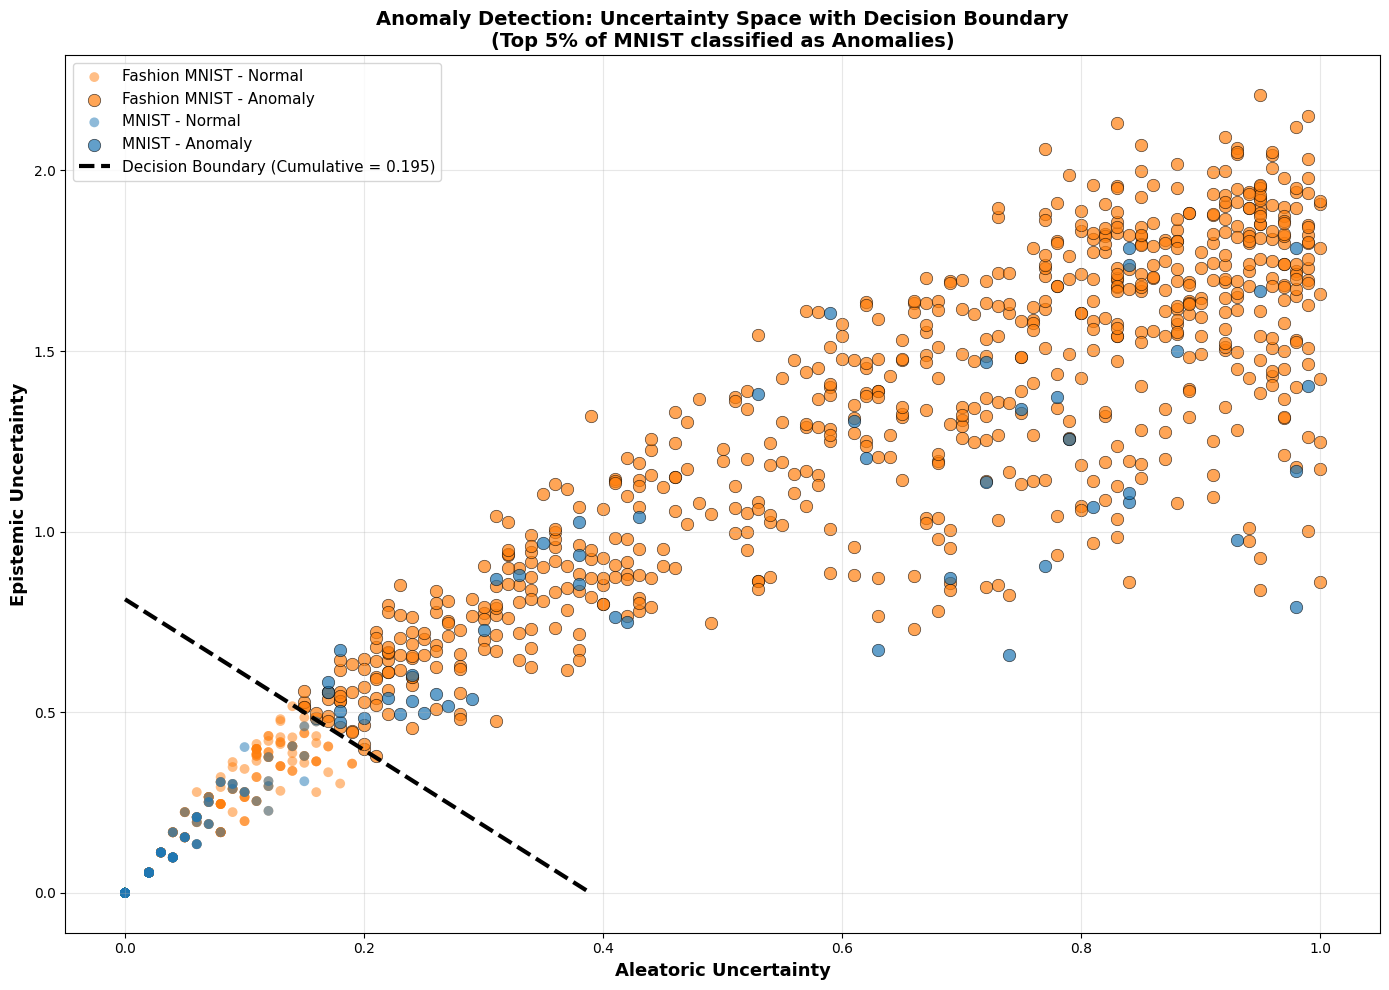

Visualization complete!

Boundary equation: 0.5 * epistemic_norm + 0.5 * aleatoric_norm = 0.194644
Where: epistemic_norm = (epistemic - -0.000) / 2.088
       aleatoric_norm = (aleatoric - 0.000) / 1.000


In [21]:
# Visualize the anomaly detection boundary in 2D space
print("\n" + "="*70)
print("ANOMALY DETECTION BOUNDARY VISUALIZATION")
print("="*70 + "\n")

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data for visualization (same as before)
mnist_sample_size = min(1000, len(epistemic_mnist))
mnist_indices = np.random.choice(len(epistemic_mnist), mnist_sample_size, replace=False)
epistemic_mnist_sample = epistemic_mnist[mnist_indices]
aleatoric_mnist_sample = aleatoric_mnist[mnist_indices]

fmnist_sample_size = min(1000, len(epistemic_fmnist))
epistemic_fmnist_sample = epistemic_fmnist[:fmnist_sample_size]
aleatoric_fmnist_sample = aleatoric_fmnist[:fmnist_sample_size]

# Calculate cumulative uncertainties for boundary
epi_min, epi_max = epistemic_mnist.min(), epistemic_mnist.max()
ale_min, ale_max = aleatoric_mnist.min(), aleatoric_mnist.max()

epistemic_norm_sample_mnist = (epistemic_mnist_sample - epi_min) / (epi_max - epi_min + 1e-10)
aleatoric_norm_sample_mnist = (aleatoric_mnist_sample - ale_min) / (ale_max - ale_min + 1e-10)
cumulative_sample_mnist = 0.5 * epistemic_norm_sample_mnist + 0.5 * aleatoric_norm_sample_mnist

epistemic_norm_sample_fmnist = (epistemic_fmnist_sample - epi_min) / (epi_max - epi_min + 1e-10)
aleatoric_norm_sample_fmnist = (aleatoric_fmnist_sample - ale_min) / (ale_max - ale_min + 1e-10)
cumulative_sample_fmnist = 0.5 * epistemic_norm_sample_fmnist + 0.5 * aleatoric_norm_sample_fmnist

# Normalize threshold to sample space
threshold_norm = (anomaly_threshold - 0) / (1 - 0)

# Plot Fashion MNIST (non-anomaly)
fmnist_mask = cumulative_sample_fmnist < threshold_norm
scatter1 = ax.scatter(aleatoric_fmnist_sample[fmnist_mask], epistemic_fmnist_sample[fmnist_mask], 
                      alpha=0.5, s=50, color='#ff7f0e', label=f'Fashion MNIST - Normal',
                      edgecolors='none')

# Plot Fashion MNIST anomalies
fmnist_anom_mask = cumulative_sample_fmnist >= threshold_norm
scatter2 = ax.scatter(aleatoric_fmnist_sample[fmnist_anom_mask], epistemic_fmnist_sample[fmnist_anom_mask], 
                      alpha=0.7, s=80, color='#ff7f0e', marker='o', label=f'Fashion MNIST - Anomaly',
                      edgecolors='black', linewidth=0.5)

# Plot MNIST (non-anomaly)
mnist_mask = cumulative_sample_mnist < threshold_norm
scatter3 = ax.scatter(aleatoric_mnist_sample[mnist_mask], epistemic_mnist_sample[mnist_mask], 
                      alpha=0.5, s=50, color='#1f77b4', label=f'MNIST - Normal',
                      edgecolors='none')

# Plot MNIST anomalies
mnist_anom_mask = cumulative_sample_mnist >= threshold_norm
scatter4 = ax.scatter(aleatoric_mnist_sample[mnist_anom_mask], epistemic_mnist_sample[mnist_anom_mask], 
                      alpha=0.7, s=80, color='#1f77b4', marker='o', label=f'MNIST - Anomaly',
                      edgecolors='black', linewidth=0.5)

# Draw decision boundary: cumulative = 0.5 * epistemic_norm + 0.5 * aleatoric_norm = threshold
# Rearranged: epistemic = 2 * threshold - aleatoric
ale_range = np.linspace(aleatoric_mnist.min(), aleatoric_mnist.max(), 200)
ale_norm_range = (ale_range - ale_min) / (ale_max - ale_min + 1e-10)
epi_norm_boundary = 2 * threshold_norm - ale_norm_range
epi_boundary = epi_norm_boundary * (epi_max - epi_min) + epi_min

# Only plot valid part of boundary
valid_mask = (epi_boundary >= epistemic_mnist.min()) & (epi_boundary <= epistemic_mnist.max())
ax.plot(ale_range[valid_mask], epi_boundary[valid_mask], 'k--', linewidth=3, 
        label=f'Decision Boundary (Cumulative = {anomaly_threshold:.3f})', zorder=10)

ax.set_xlabel('Aleatoric Uncertainty', fontsize=13, fontweight='bold')
ax.set_ylabel('Epistemic Uncertainty', fontsize=13, fontweight='bold')
ax.set_title('Anomaly Detection: Uncertainty Space with Decision Boundary\n(Top 5% of MNIST classified as Anomalies)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")
print(f"\nBoundary equation: 0.5 * epistemic_norm + 0.5 * aleatoric_norm = {threshold_norm:.6f}")
print(f"Where: epistemic_norm = (epistemic - {epi_min:.3f}) / {epi_max - epi_min:.3f}")
print(f"       aleatoric_norm = (aleatoric - {ale_min:.3f}) / {ale_max - ale_min:.3f}")

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

# Class names: 0-9 for digits, 10 for anomaly
class_names_with_anomaly = [str(i) for i in range(10)] + ['Anomaly']
class_names_digits = [str(i) for i in range(10)]

# Confusion matrix for MNIST (full 11x11)
cm_mnist_full = confusion_matrix(y_test, y_pred_with_anomaly_mnist, labels=range(11))

# Keep only rows 0-9 (true labels for MNIST are only digits, no Anomaly label)
cm_mnist_anom = cm_mnist_full[:-1, :]

print("=" * 80)
print("MNIST CONFUSION MATRIX (with Anomaly Detection)")
print("=" * 80)
print("\nConfusion Matrix shape:", cm_mnist_anom.shape)
print("\nRow labels (true): digits 0-9 (no Anomaly - MNIST only has digit labels)")
print("Column labels (predicted): digits 0-9 + Anomaly\n")

# Create a formatted version with labels
cm_mnist_df = pd.DataFrame(cm_mnist_anom, 
                            index=[f'True {name}' for name in class_names_digits],
                            columns=[f'Pred {name}' for name in class_names_with_anomaly])
print(cm_mnist_df)

# Classification report
print("\n" + "=" * 80)
print("MNIST CLASSIFICATION REPORT (with Anomaly Detection)")
print("=" * 80)
print(classification_report(y_test, y_pred_with_anomaly_mnist, 
                          target_names=class_names_with_anomaly, 
                          digits=4, zero_division=0))

# Overall accuracy
mnist_accuracy_anom = np.mean(y_test == y_pred_with_anomaly_mnist)
print(f"Overall Accuracy (MNIST): {mnist_accuracy_anom:.4f} ({mnist_accuracy_anom*100:.2f}%)")


MNIST CONFUSION MATRIX (with Anomaly Detection)

Confusion Matrix shape: (10, 11)

Row labels (true): digits 0-9 (no Anomaly - MNIST only has digit labels)
Column labels (predicted): digits 0-9 + Anomaly

        Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True 0     951       0       0       0       0       0       0       0   
True 1       0    1110       0       0       0       0       0       0   
True 2       0       0     978       0       0       0       0       1   
True 3       0       0       0     959       0       0       0       1   
True 4       0       0       0       0     924       0       2       0   
True 5       0       0       0       7       0     829       0       0   
True 6       2       1       0       0       1       2     911       0   
True 7       0       0       3       0       0       0       0     956   
True 8       0       0       1       0       1       0       0       1   
True 9       0       0       0       1       3       0 

In [23]:
# Confusion matrix for Fashion MNIST 
# Create true labels array (all samples are Anomalies for Fashion MNIST)
y_fashion_true_anomaly = np.full(len(y_fashion), 10)

cm_fmnist_full = confusion_matrix(y_fashion_true_anomaly, y_pred_with_anomaly_fmnist, labels=range(11))

# Keep only last row (true label is always Anomaly for Fashion MNIST)
cm_fmnist_anom = cm_fmnist_full[-1:, :]

print("\n" + "=" * 80)
print("FASHION MNIST CONFUSION MATRIX (with Anomaly Detection)")
print("=" * 80)
print("\nConfusion Matrix shape:", cm_fmnist_anom.shape)
print("\nRow labels (true): Anomaly (all Fashion MNIST samples are OOD anomalies)")
print("Column labels (predicted): digits 0-9 + Anomaly\n")
print("Note: All Fashion MNIST samples are expected to be classified as 'Anomaly' (class 10)\n")

# Create a formatted version with labels
cm_fmnist_df = pd.DataFrame(cm_fmnist_anom,
                             index=['True Anomaly'],
                             columns=[f'Pred {name}' for name in class_names_with_anomaly])
print(cm_fmnist_df)

# Key metrics for anomaly detection
print("\n" + "=" * 80)
print("ANOMALY DETECTION SUMMARY")
print("=" * 80)
print(f"\nMNIST:")
print(f"  - Total samples: {len(y_test)}")
print(f"  - Flagged as anomalies: {(y_pred_with_anomaly_mnist == 10).sum()} ({(y_pred_with_anomaly_mnist == 10).sum() / len(y_test) * 100:.2f}%)")
print(f"  - Correctly classified as digits: {(y_pred_with_anomaly_mnist < 10).sum()} ({(y_pred_with_anomaly_mnist < 10).sum() / len(y_test) * 100:.2f}%)")

print(f"\nFashion MNIST:")
print(f"  - Total samples: {len(y_fashion_true_anomaly)}")
print(f"  - Correctly flagged as anomalies: {cm_fmnist_anom[0, -1]} ({cm_fmnist_anom[0, -1] / len(y_fashion_true_anomaly) * 100:.2f}%)")
print(f"  - Incorrectly classified as digits: {cm_fmnist_anom[0, :-1].sum()} ({cm_fmnist_anom[0, :-1].sum() / len(y_fashion_true_anomaly) * 100:.2f}%)")
print(f"  - Anomaly detection rate: {cm_fmnist_anom[0, -1] / len(y_fashion_true_anomaly) * 100:.2f}%")



FASHION MNIST CONFUSION MATRIX (with Anomaly Detection)

Confusion Matrix shape: (1, 11)

Row labels (true): Anomaly (all Fashion MNIST samples are OOD anomalies)
Column labels (predicted): digits 0-9 + Anomaly

Note: All Fashion MNIST samples are expected to be classified as 'Anomaly' (class 10)

              Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
True Anomaly       0       0     178       0       0      60       3       1   

              Pred 8  Pred 9  Pred Anomaly  
True Anomaly      11       0           747  

ANOMALY DETECTION SUMMARY

MNIST:
  - Total samples: 10000
  - Flagged as anomalies: 500 (5.00%)
  - Correctly classified as digits: 9500 (95.00%)

Fashion MNIST:
  - Total samples: 1000
  - Correctly flagged as anomalies: 747 (74.70%)
  - Incorrectly classified as digits: 253 (25.30%)
  - Anomaly detection rate: 74.70%


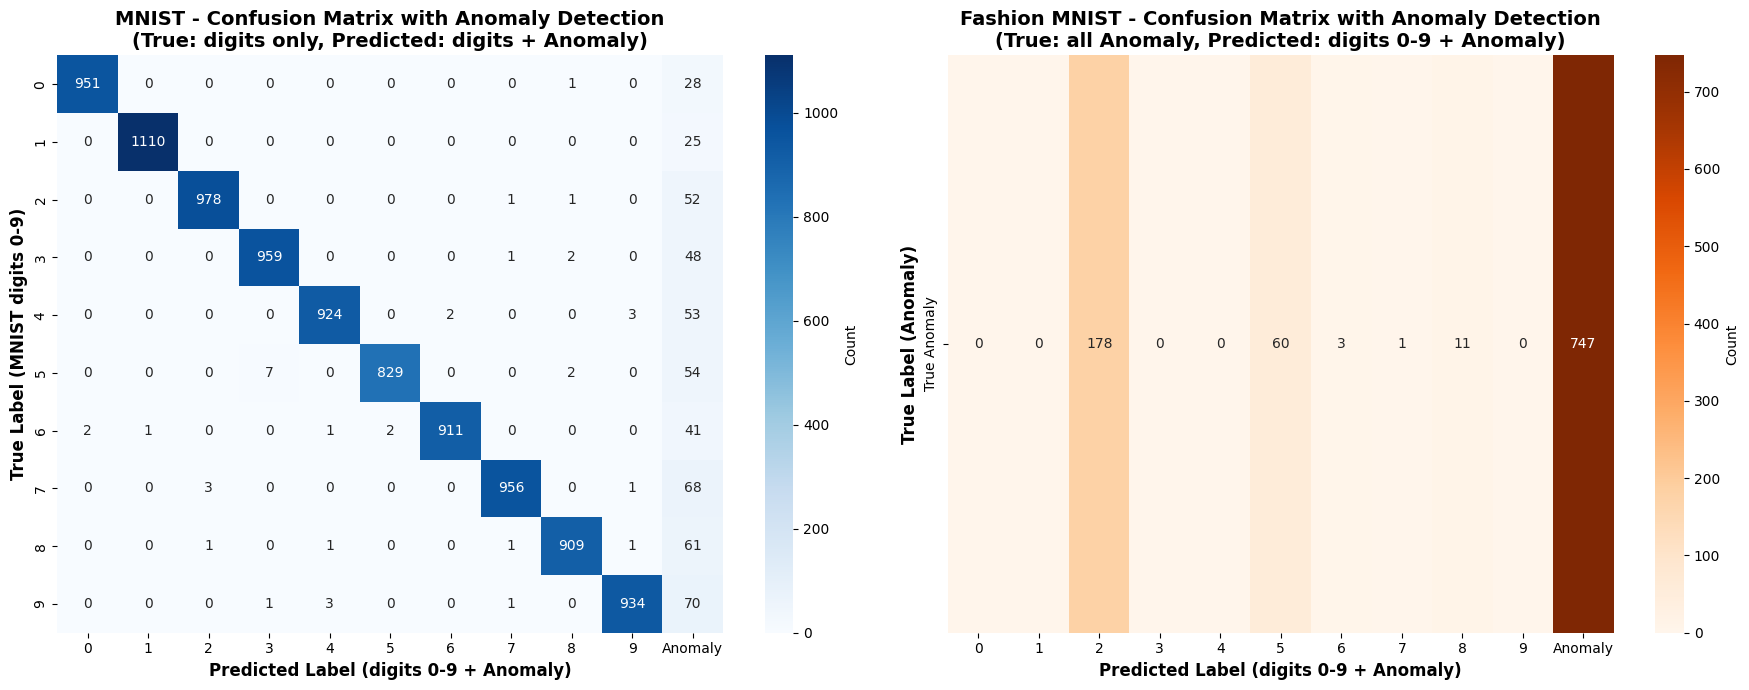

Confusion matrices visualization complete!


In [24]:
# Visualize confusion matrices as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# MNIST heatmap (10 rows for true digits, 11 columns for predictions)
sns.heatmap(cm_mnist_anom, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_with_anomaly, 
            yticklabels=class_names_digits,
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title('MNIST - Confusion Matrix with Anomaly Detection\n(True: digits only, Predicted: digits + Anomaly)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label (MNIST digits 0-9)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label (digits 0-9 + Anomaly)', fontsize=12, fontweight='bold')

# Fashion MNIST heatmap (1 row for Anomaly true label, 11 columns for predictions)
sns.heatmap(cm_fmnist_anom, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_with_anomaly,
            yticklabels=['True Anomaly'],
            cbar_kws={'label': 'Count'},
            ax=axes[1])
axes[1].set_title('Fashion MNIST - Confusion Matrix with Anomaly Detection\n(True: all Anomaly, Predicted: digits 0-9 + Anomaly)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label (Anomaly)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label (digits 0-9 + Anomaly)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Confusion matrices visualization complete!")


Fashion MNIST Samples Misclassified as Digits (not Anomalies)

Total misclassified: 253 out of 1000 (25.30%)
These are samples with LOW uncertainty (below threshold of 0.194644)



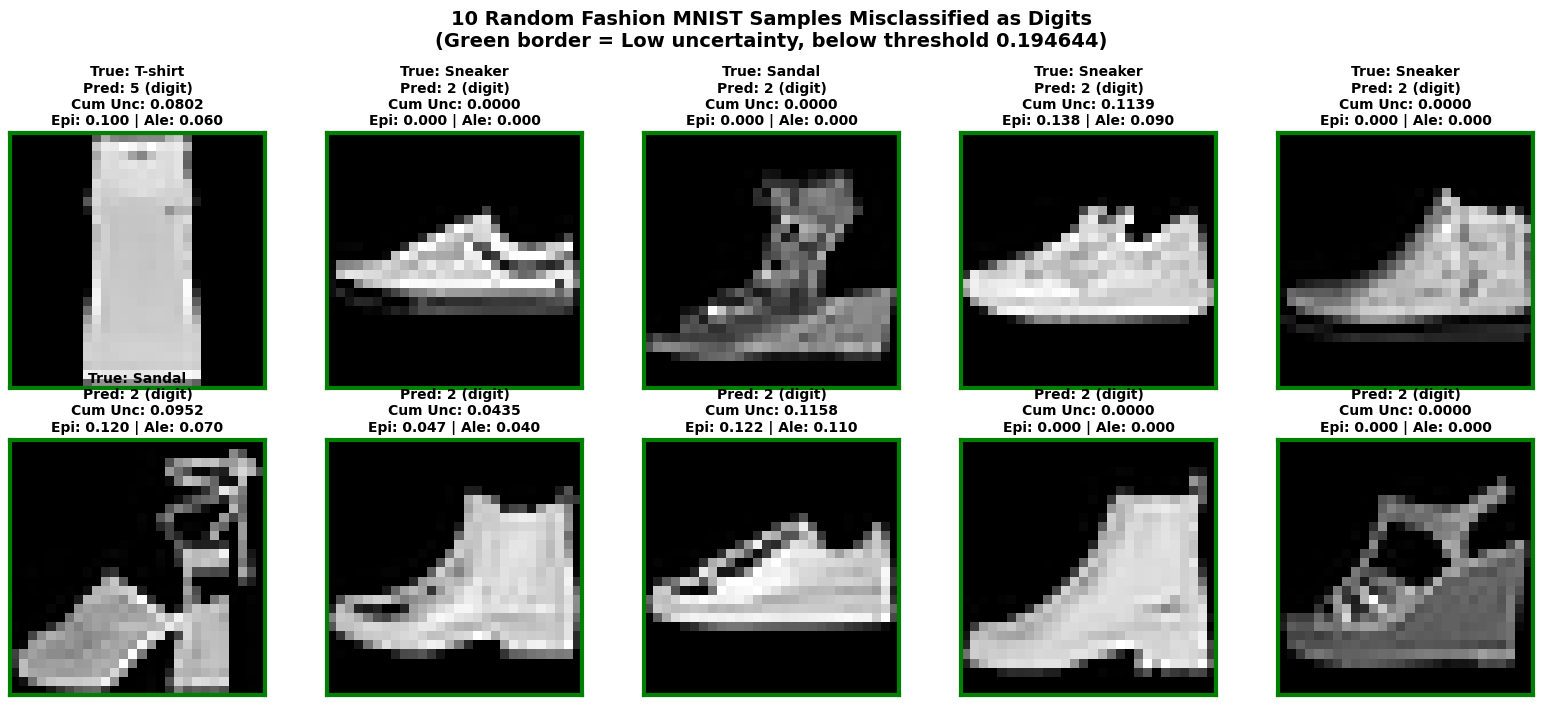


Note: Green borders indicate samples with cumulative uncertainty below the anomaly threshold (0.161307)
These samples are borderline cases that the model fails to detect as anomalies.


In [25]:
# Find Fashion MNIST samples misclassified as digits (not predicted as Anomaly)
misclassified_mask = y_pred_with_anomaly_fmnist < 10  # Predicted as digit (0-9), not Anomaly (10)
misclassified_indices = np.where(misclassified_mask)[0]

print("=" * 80)
print(f"Fashion MNIST Samples Misclassified as Digits (not Anomalies)")
print("=" * 80)
print(f"\nTotal misclassified: {len(misclassified_indices)} out of {len(y_fashion_true_anomaly)} ({len(misclassified_indices)/len(y_fashion_true_anomaly)*100:.2f}%)")
print(f"These are samples with LOW uncertainty (below threshold of {anomaly_threshold:.6f})\n")

# Select 10 random misclassified samples
n_display = min(10, len(misclassified_indices))
random_misclassified = np.random.choice(misclassified_indices, size=n_display, replace=False)

# Create visualization
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

fashion_class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

for idx_plot, sample_idx in enumerate(random_misclassified):
    ax = axes[idx_plot]
    
    # Get image and prediction
    img = fashion_images[sample_idx].reshape(28, 28)
    true_label = y_fashion[sample_idx]
    pred_label = y_pred_with_anomaly_fmnist[sample_idx]
    
    # Get uncertainty values
    epi_val = epistemic_fmnist[sample_idx]
    ale_val = aleatoric_fmnist[sample_idx]
    epi_norm_val = epistemic_norm_sample_fmnist[sample_idx]
    ale_norm_val = aleatoric_norm_sample_fmnist[sample_idx]
    cum_val = cumulative_sample_fmnist[sample_idx]
    
    # Display image
    ax.imshow(img, cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Title with info
    title = f"True: {fashion_class_names[true_label]}\nPred: {pred_label} (digit)\n"
    title += f"Cum Unc: {cum_val:.4f}\n"
    title += f"Epi: {epi_norm_val:.3f} | Ale: {ale_norm_val:.3f}"
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    
    # Color border based on whether it's below threshold
    if cum_val < anomaly_threshold:
        ax.spines['bottom'].set_color('green')
        ax.spines['top'].set_color('green')
        ax.spines['right'].set_color('green')
        ax.spines['left'].set_color('green')
        ax.spines['bottom'].set_linewidth(3)
        ax.spines['top'].set_linewidth(3)
        ax.spines['right'].set_linewidth(3)
        ax.spines['left'].set_linewidth(3)

plt.suptitle(f'10 Random Fashion MNIST Samples Misclassified as Digits\n(Green border = Low uncertainty, below threshold {anomaly_threshold:.6f})', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nNote: Green borders indicate samples with cumulative uncertainty below the anomaly threshold (0.161307)")
print("These samples are borderline cases that the model fails to detect as anomalies.")

# AUTOENCODEURS

In [26]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define and configure Autoencoder model
# Architecture: 784 -> 256 -> 128 -> 10 -> 128 -> 256 -> 784
autoencoder = MLPRegressor(
    hidden_layer_sizes=(512, 256, 128, 64, 10, 64, 128, 256, 512),
    activation='relu',
    max_iter=300,
    batch_size=128,
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=0
)

print("\nAutoencoder Configuration:")
print(f"  - Architecture: 784 -> 512 -> 256 -> 128 -> 64 -> 10 -> 64 -> 128 -> 256 -> 512 -> 784")
print(f"  - Hidden layers: {autoencoder.hidden_layer_sizes}")
print(f"  - Activation: {autoencoder.activation}")
print(f"  - Max iterations: {autoencoder.max_iter}")
print(f"  - Learning rate: {autoencoder.learning_rate_init}")
print(f"  - Early stopping: {autoencoder.early_stopping}")


Autoencoder Configuration:
  - Architecture: 784 -> 512 -> 256 -> 128 -> 64 -> 10 -> 64 -> 128 -> 256 -> 512 -> 784
  - Hidden layers: (512, 256, 128, 64, 10, 64, 128, 256, 512)
  - Activation: relu
  - Max iterations: 300
  - Learning rate: 0.001
  - Early stopping: True


In [27]:
# Train autoencoder on training data
print("\n" + "="*70)
print("TRAINING AUTOENCODER ON TRAINING DATA")
print("="*70 + "\n")

print("Training autoencoder...")
start_time = time.time()
autoencoder.fit(X_train, X_train)  # Input = Output (reconstruct input)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds\n")

# Evaluate on both train and test sets
X_pred_train = autoencoder.predict(X_train)
X_pred_test = autoencoder.predict(X_test)

print("TRAINING SET METRICS:")
train_mse = mean_squared_error(X_train, X_pred_train)
train_mae = mean_absolute_error(X_train, X_pred_train)
train_rmse = np.sqrt(train_mse)

print(f"  - MSE (Mean Squared Error):   {train_mse:.6f}")
print(f"  - RMSE (Root Mean Squared Error): {train_rmse:.6f}")
print(f"  - MAE (Mean Absolute Error):  {train_mae:.6f}")

print("\nTEST SET METRICS:")
test_mse = mean_squared_error(X_test, X_pred_test)
test_mae = mean_absolute_error(X_test, X_pred_test)
test_rmse = np.sqrt(test_mse)

print(f"  - MSE (Mean Squared Error):   {test_mse:.6f}")
print(f"  - RMSE (Root Mean Squared Error): {test_rmse:.6f}")
print(f"  - MAE (Mean Absolute Error):  {test_mae:.6f}")


TRAINING AUTOENCODER ON TRAINING DATA

Training autoencoder...
Training completed in 1742.49 seconds

Training completed in 1742.49 seconds

TRAINING SET METRICS:
TRAINING SET METRICS:
  - MSE (Mean Squared Error):   0.015599
  - RMSE (Root Mean Squared Error): 0.124897
  - MAE (Mean Absolute Error):  0.058882

TEST SET METRICS:
  - MSE (Mean Squared Error):   0.016968
  - RMSE (Root Mean Squared Error): 0.130263
  - MAE (Mean Absolute Error):  0.060758
  - MSE (Mean Squared Error):   0.015599
  - RMSE (Root Mean Squared Error): 0.124897
  - MAE (Mean Absolute Error):  0.058882

TEST SET METRICS:
  - MSE (Mean Squared Error):   0.016968
  - RMSE (Root Mean Squared Error): 0.130263
  - MAE (Mean Absolute Error):  0.060758


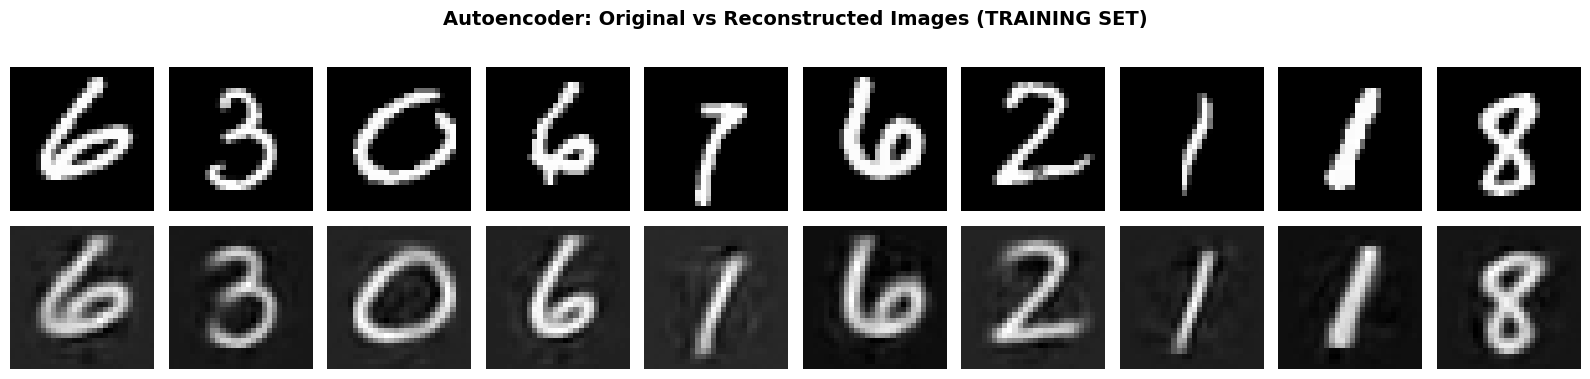


Autoencoder Reconstruction Examples (TRAINING SET):
  - Displayed 10 random examples


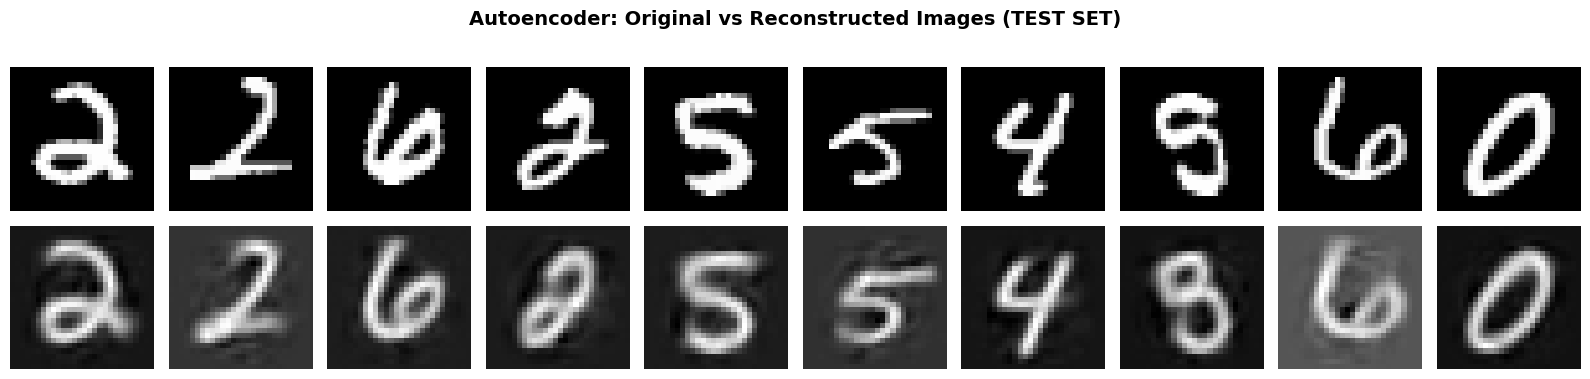


Autoencoder Reconstruction Examples (TEST SET):
  - Displayed 10 random examples


In [28]:
# Visualization of autoencoder reconstructions
# Display original vs reconstructed images from TRAINING set

fig1, axes1 = plt.subplots(2, 10, figsize=(16, 4))
fig1.suptitle('Autoencoder: Original vs Reconstructed Images (TRAINING SET)', 
             fontsize=14, fontweight='bold')

# Select 10 random images from training set
train_indices = np.random.choice(len(X_train), 10, replace=False)

# Original images
for idx, img_idx in enumerate(train_indices):
    original_img = X_train[img_idx].reshape(28, 28)
    axes1[0, idx].imshow(original_img, cmap='gray')
    axes1[0, idx].axis('off')
    if idx == 0:
        axes1[0, idx].set_ylabel('Original', fontsize=11, fontweight='bold')

# Reconstructed images
for idx, img_idx in enumerate(train_indices):
    reconstructed_img = X_pred_train[img_idx].reshape(28, 28)
    axes1[1, idx].imshow(reconstructed_img, cmap='gray')
    axes1[1, idx].axis('off')
    if idx == 0:
        axes1[1, idx].set_ylabel('Reconstructed', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAutoencoder Reconstruction Examples (TRAINING SET):")
print(f"  - Displayed {len(train_indices)} random examples")

# Visualization of autoencoder reconstructions
# Display original vs reconstructed images from TEST set

fig2, axes2 = plt.subplots(2, 10, figsize=(16, 4))
fig2.suptitle('Autoencoder: Original vs Reconstructed Images (TEST SET)', 
             fontsize=14, fontweight='bold')

# Select 10 random images from test set
test_indices = np.random.choice(len(X_test), 10, replace=False)

# Original images
for idx, img_idx in enumerate(test_indices):
    original_img = X_test[img_idx].reshape(28, 28)
    axes2[0, idx].imshow(original_img, cmap='gray')
    axes2[0, idx].axis('off')
    if idx == 0:
        axes2[0, idx].set_ylabel('Original', fontsize=11, fontweight='bold')

# Reconstructed images
for idx, img_idx in enumerate(test_indices):
    reconstructed_img = X_pred_test[img_idx].reshape(28, 28)
    axes2[1, idx].imshow(reconstructed_img, cmap='gray')
    axes2[1, idx].axis('off')
    if idx == 0:
        axes2[1, idx].set_ylabel('Reconstructed', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAutoencoder Reconstruction Examples (TEST SET):")
print(f"  - Displayed {len(test_indices)} random examples")

## Prédire les classes avec un random forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Extract features from the seventh-to-last layer (64 neurons)
# We need to get the activations from the hidden layer before the output layer
# Using MLPRegressor's _forward_pass or by creating a modified predictor

# Method: Use the last hidden layer's activation as features
# The MLP stores coefs_ and intercepts_ for each layer

def get_hidden_layer_activations(model, X, layer_idx=-7):
    """
    Extract activations from a specific hidden layer of the MLP.
    layer_idx=-7 means the seventh-to-last layer (before output)
    """
    activations = X.copy()
    # Forward pass through all layers except the last one
    for i in range(len(model.coefs_) + layer_idx + 1):
        activations = np.dot(activations, model.coefs_[i]) + model.intercepts_[i]
        # Apply activation function (ReLU for hidden layers)
        if i < len(model.coefs_) + layer_idx:
            activations = np.maximum(activations, 0)  # ReLU activation
    return activations

print("\n" + "="*70)
print("EXTRACTING FEATURES FROM SECOND-TO-LAST LAYER")
print("="*70 + "\n")

# Extract features from training and test sets
print("Extracting 64-dimensional features from second-to-last layer...")
X_train_hidden = get_hidden_layer_activations(autoencoder, X_train, layer_idx=-7)
X_test_hidden = get_hidden_layer_activations(autoencoder, X_test, layer_idx=-7)

print(f"✓ Training features shape: {X_train_hidden.shape}")
print(f"✓ Test features shape: {X_test_hidden.shape}")
print(f"✓ Feature dimension: {X_train_hidden.shape[1]} neurons from second-to-last layer")



EXTRACTING FEATURES FROM SECOND-TO-LAST LAYER

Extracting 64-dimensional features from second-to-last layer...
✓ Training features shape: (60000, 64)
✓ Test features shape: (10000, 64)
✓ Feature dimension: 64 neurons from second-to-last layer
✓ Training features shape: (60000, 64)
✓ Test features shape: (10000, 64)
✓ Feature dimension: 64 neurons from second-to-last layer


In [30]:
# Train Random Forest classifier on MLP hidden layer features
print("\n" + "="*70)
print("TRAINING RANDOM FOREST ON HIDDEN LAYER FEATURES")
print("="*70 + "\n")

# Create and configure Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Random Forest Configuration:")
print(f"  - Number of estimators: {rf.n_estimators}")
print(f"  - Max depth: {rf.max_depth}")
print(f"  - Min samples split: {rf.min_samples_split}")
print(f"  - Min samples leaf: {rf.min_samples_leaf}")

# Train the Random Forest
print("\nTraining Random Forest...")
start_time = time.time()
rf.fit(X_train_hidden, y_train)
train_time_rf = time.time() - start_time
print(f"\n✓ Training completed in {train_time_rf:.2f} seconds")

# Make predictions
y_pred_train_rf = rf.predict(X_train_hidden)
y_pred_test_rf = rf.predict(X_test_hidden)

# Evaluate performance
print("\n" + "="*70)
print("RANDOM FOREST PERFORMANCE EVALUATION")
print("="*70)

print("\nTRAINING SET METRICS:")
train_accuracy_rf = accuracy_score(y_train, y_pred_train_rf)
train_precision_rf = precision_score(y_train, y_pred_train_rf, average='macro', zero_division=0)
train_recall_rf = recall_score(y_train, y_pred_train_rf, average='macro', zero_division=0)
train_f1_rf = f1_score(y_train, y_pred_train_rf, average='macro', zero_division=0)

print(f"  - Accuracy:        {train_accuracy_rf:.4f}")
print(f"  - Precision (macro): {train_precision_rf:.4f}")
print(f"  - Recall (macro):    {train_recall_rf:.4f}")
print(f"  - F1-Score (macro):  {train_f1_rf:.4f}")

print("\nTEST SET METRICS:")
test_accuracy_rf = accuracy_score(y_test, y_pred_test_rf)
test_precision_rf = precision_score(y_test, y_pred_test_rf, average='macro', zero_division=0)
test_recall_rf = recall_score(y_test, y_pred_test_rf, average='macro', zero_division=0)
test_f1_rf = f1_score(y_test, y_pred_test_rf, average='macro', zero_division=0)

print(f"  - Accuracy:        {test_accuracy_rf:.4f}")
print(f"  - Precision (macro): {test_precision_rf:.4f}")
print(f"  - Recall (macro):    {test_recall_rf:.4f}")
print(f"  - F1-Score (macro):  {test_f1_rf:.4f}")

# Comparison with MLP
print("\n" + "="*70)
print("COMPARISON: MLP vs Random Forest (on test set)")
print("="*70)
print(f"\nMLP Accuracy:           {test_accuracy:.4f}")
print(f"Random Forest Accuracy: {test_accuracy_rf:.4f}")
print(f"Difference:             {test_accuracy_rf - test_accuracy:+.4f}")


TRAINING RANDOM FOREST ON HIDDEN LAYER FEATURES

Random Forest Configuration:
  - Number of estimators: 100
  - Max depth: 20
  - Min samples split: 5
  - Min samples leaf: 2

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.4s



✓ Training completed in 7.61 seconds

RANDOM FOREST PERFORMANCE EVALUATION

TRAINING SET METRICS:
  - Accuracy:        0.9942
  - Precision (macro): 0.9941
  - Recall (macro):    0.9942
  - F1-Score (macro):  0.9942

TEST SET METRICS:
  - Accuracy:        0.9566
  - Precision (macro): 0.9562
  - Recall (macro):    0.9561
  - F1-Score (macro):  0.9561

COMPARISON: MLP vs Random Forest (on test set)

MLP Accuracy:           0.9801
Random Forest Accuracy: 0.9566
Difference:             -0.0235


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.5s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


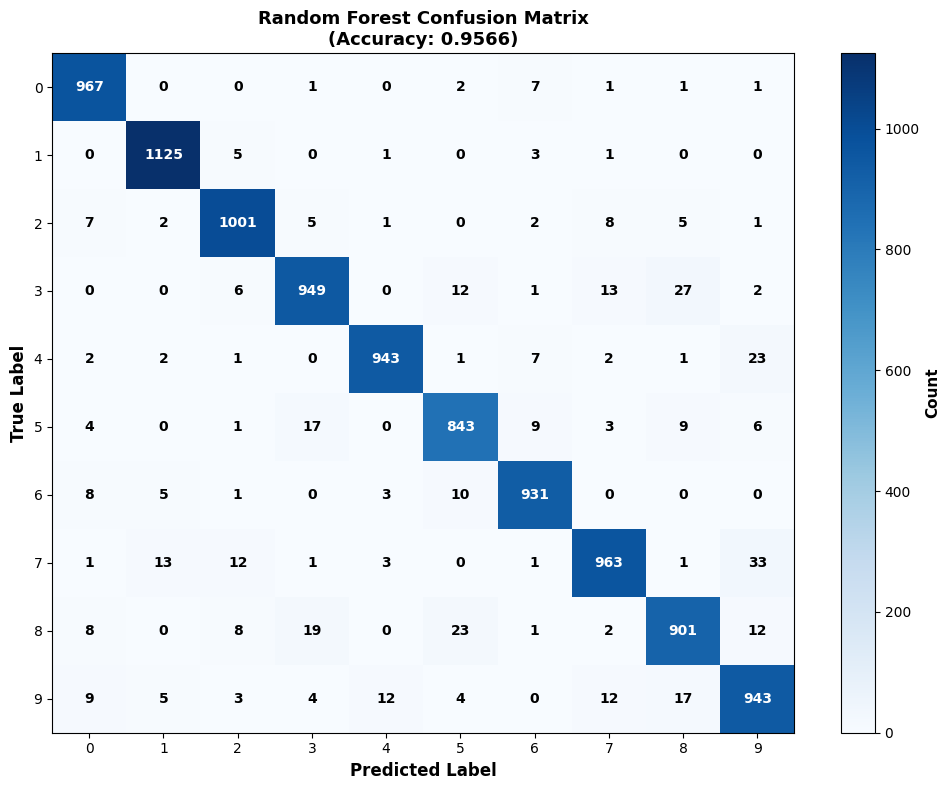

In [46]:
# Visualization - Confusion Matrix for Random Forest
fig, ax = plt.subplots(figsize=(10, 8))

# Compute confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_test_rf)

# Plot confusion matrix
im = ax.imshow(cm_rf, cmap='Blues', aspect='auto')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Random Forest Confusion Matrix\n(Accuracy: {test_accuracy_rf:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        count = cm_rf[i, j]
        text_color = 'white' if count > cm_rf.max() / 2 else 'black'
        ax.text(j, i, str(count), ha='center', va='center',
                color=text_color, fontsize=10, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## On fait passer FashionMNIST dans la pipeline

In [32]:
# Prepare Fashion MNIST data for the pipeline
print("\n" + "="*70)
print("PREPARING FASHION MNIST DATA FOR THE PIPELINE")
print("="*70 + "\n")

# Flatten and normalize Fashion MNIST images
X_fashion = fashion_images.reshape(fashion_images.shape[0], -1) / 255.0
y_fashion = fashion_labels

print(f"Fashion MNIST data shape: {X_fashion.shape}")
print(f"Fashion MNIST labels shape: {y_fashion.shape}")

# Extract hidden layer features for Fashion MNIST using the trained MLP
X_fashion_hidden = get_hidden_layer_activations(mlp, X_fashion, layer_idx=-2)
print(f"Fashion MNIST hidden features shape: {X_fashion_hidden.shape}")

# Make predictions with MLP and Random Forest on Fashion MNIST
y_pred_fashion_mlp = mlp.predict(X_fashion)
y_pred_fashion_rf = rf.predict(X_fashion_hidden)

print(f"\n✓ MLP predictions on Fashion MNIST: {y_pred_fashion_mlp.shape}")
print(f"✓ Random Forest predictions on Fashion MNIST: {y_pred_fashion_rf.shape}")

# Calculate accuracies
fashion_accuracy_mlp = accuracy_score(y_fashion, y_pred_fashion_mlp)
fashion_accuracy_rf = accuracy_score(y_fashion, y_pred_fashion_rf)

print(f"\nFashion MNIST Results:")
print(f"  - MLP Accuracy:           {fashion_accuracy_mlp:.4f}")
print(f"  - Random Forest Accuracy: {fashion_accuracy_rf:.4f}")



PREPARING FASHION MNIST DATA FOR THE PIPELINE

Fashion MNIST data shape: (1000, 784)
Fashion MNIST labels shape: (1000,)
Fashion MNIST hidden features shape: (1000, 64)

✓ MLP predictions on Fashion MNIST: (1000,)
✓ Random Forest predictions on Fashion MNIST: (1000,)

Fashion MNIST Results:
  - MLP Accuracy:           0.1040
  - Random Forest Accuracy: 0.0740


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


In [33]:
# Estimate Epistemic and Aleatoric Uncertainty for Random Forest predictions
print("\n" + "="*70)
print("ESTIMATING EPISTEMIC AND ALEATORIC UNCERTAINTY")
print("="*70 + "\n")

# Get prediction probabilities from Random Forest
from scipy import stats

# Get probability predictions from each tree in the forest
def get_rf_uncertainties(model, X_data):
    """
    Estimate epistemic and aleatoric uncertainty from Random Forest.
    
    Epistemic uncertainty: disagreement between trees (entropy of the ensemble prediction distribution)
                          - Measures model uncertainty: would decrease with more training data
    Aleatoric uncertainty: irreducible uncertainty in the data
                          - We approximate it using the margin (difference between top 2 classes)
    """
    # Get predictions from each tree
    n_trees = model.n_estimators
    predictions = np.array([tree.predict(X_data) for tree in model.estimators_])
    
    # Initialize uncertainties
    epistemic_uncertainty = np.zeros(X_data.shape[0])
    aleatoric_uncertainty = np.zeros(X_data.shape[0])
    
    # Process each sample
    for i in range(X_data.shape[0]):
        # Convert predictions to int to avoid casting issues
        preds_i = predictions[:, i].astype(int)
        
        # Count votes for each class across trees
        votes = np.bincount(preds_i, minlength=10)
        prob_dist = votes / n_trees
        
        # Epistemic uncertainty: entropy of the ensemble vote distribution
        # High when trees strongly disagree on the prediction
        epistemic_uncertainty[i] = -np.sum(prob_dist * np.log(prob_dist + 1e-10))
        
        # Aleatoric uncertainty: measure of confidence in the top prediction
        # Using margin-based approach: distance between top 2 class probabilities
        sorted_probs = np.sort(prob_dist)[::-1]
        margin = sorted_probs[0] - sorted_probs[1]  # Difference between top 2
        aleatoric_uncertainty[i] = 1.0 - margin  # Invert so high margin = low uncertainty
    
    # Ensemble prediction (mode)
    ensemble_pred = np.array([int(np.argmax(np.bincount(predictions[:, i].astype(int), minlength=10))) 
                              for i in range(X_data.shape[0])])
    
    return ensemble_pred, epistemic_uncertainty, aleatoric_uncertainty

# Calculate uncertainties for MNIST test set
y_pred_mnist, epistemic_mnist, aleatoric_mnist = get_rf_uncertainties(rf, X_test_hidden)

# Calculate uncertainties for Fashion MNIST
y_pred_fmnist, epistemic_fmnist, aleatoric_fmnist = get_rf_uncertainties(rf, X_fashion_hidden)

print(f"Epistemic Uncertainty (MNIST):")
print(f"  - Mean: {epistemic_mnist.mean():.6f}")
print(f"  - Std:  {epistemic_mnist.std():.6f}")
print(f"  - Min:  {epistemic_mnist.min():.6f}")
print(f"  - Max:  {epistemic_mnist.max():.6f}")

print(f"\nAleatoric Uncertainty (MNIST):")
print(f"  - Mean: {aleatoric_mnist.mean():.6f}")
print(f"  - Std:  {aleatoric_mnist.std():.6f}")
print(f"  - Min:  {aleatoric_mnist.min():.6f}")
print(f"  - Max:  {aleatoric_mnist.max():.6f}")

print(f"\nEpistemic Uncertainty (Fashion MNIST):")
print(f"  - Mean: {epistemic_fmnist.mean():.6f}")
print(f"  - Std:  {epistemic_fmnist.std():.6f}")
print(f"  - Min:  {epistemic_fmnist.min():.6f}")
print(f"  - Max:  {epistemic_fmnist.max():.6f}")

print(f"\nAleatoric Uncertainty (Fashion MNIST):")
print(f"  - Mean: {aleatoric_fmnist.mean():.6f}")
print(f"  - Std:  {aleatoric_fmnist.std():.6f}")
print(f"  - Min:  {aleatoric_fmnist.min():.6f}")
print(f"  - Max:  {aleatoric_fmnist.max():.6f}")


ESTIMATING EPISTEMIC AND ALEATORIC UNCERTAINTY

Epistemic Uncertainty (MNIST):
  - Mean: 0.371455
  - Std:  0.448405
  - Min:  -0.000000
  - Max:  2.161144

Aleatoric Uncertainty (MNIST):
  - Mean: 0.172723
  - Std:  0.245151
  - Min:  0.000000
  - Max:  1.000000

Epistemic Uncertainty (Fashion MNIST):
  - Mean: 1.845844
  - Std:  0.162394
  - Min:  1.423837
  - Max:  2.209422

Aleatoric Uncertainty (Fashion MNIST):
  - Mean: 0.885860
  - Std:  0.087027
  - Min:  0.560000
  - Max:  1.000000
Epistemic Uncertainty (MNIST):
  - Mean: 0.371455
  - Std:  0.448405
  - Min:  -0.000000
  - Max:  2.161144

Aleatoric Uncertainty (MNIST):
  - Mean: 0.172723
  - Std:  0.245151
  - Min:  0.000000
  - Max:  1.000000

Epistemic Uncertainty (Fashion MNIST):
  - Mean: 1.845844
  - Std:  0.162394
  - Min:  1.423837
  - Max:  2.209422

Aleatoric Uncertainty (Fashion MNIST):
  - Mean: 0.885860
  - Std:  0.087027
  - Min:  0.560000
  - Max:  1.000000


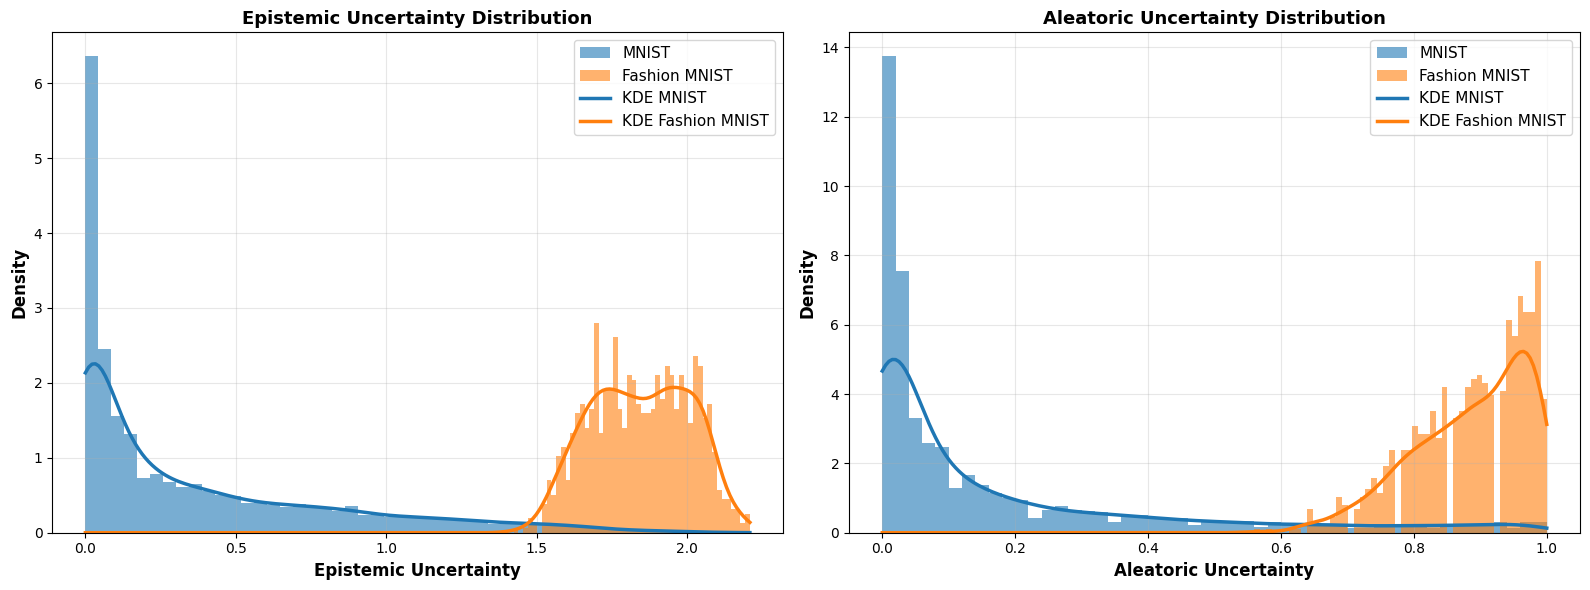

Density plot visualization complete!


In [34]:
from scipy.stats import gaussian_kde

# Create density plots comparing MNIST vs Fashion MNIST uncertainties
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define colors
color_mnist = '#1f77b4'
color_fmnist = '#ff7f0e'

# Plot 1: Epistemic Uncertainty Distribution
ax = axes[0]
ax.hist(epistemic_mnist, bins=50, alpha=0.6, label='MNIST', color=color_mnist, density=True)
ax.hist(epistemic_fmnist, bins=50, alpha=0.6, label='Fashion MNIST', color=color_fmnist, density=True)

# Add KDE curves
try:
    kde_epi_mnist = gaussian_kde(epistemic_mnist)
    kde_epi_fmnist = gaussian_kde(epistemic_fmnist)
    x_range = np.linspace(min(epistemic_mnist.min(), epistemic_fmnist.min()), 
                          max(epistemic_mnist.max(), epistemic_fmnist.max()), 200)
    ax.plot(x_range, kde_epi_mnist(x_range), color=color_mnist, linewidth=2.5, label='KDE MNIST')
    ax.plot(x_range, kde_epi_fmnist(x_range), color=color_fmnist, linewidth=2.5, label='KDE Fashion MNIST')
except:
    pass

ax.set_xlabel('Epistemic Uncertainty', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Epistemic Uncertainty Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Aleatoric Uncertainty Distribution
ax = axes[1]
ax.hist(aleatoric_mnist, bins=50, alpha=0.6, label='MNIST', color=color_mnist, density=True)
ax.hist(aleatoric_fmnist, bins=50, alpha=0.6, label='Fashion MNIST', color=color_fmnist, density=True)

# Add KDE curves
try:
    kde_ale_mnist = gaussian_kde(aleatoric_mnist)
    kde_ale_fmnist = gaussian_kde(aleatoric_fmnist)
    x_range = np.linspace(min(aleatoric_mnist.min(), aleatoric_fmnist.min()), 
                          max(aleatoric_mnist.max(), aleatoric_fmnist.max()), 200)
    ax.plot(x_range, kde_ale_mnist(x_range), color=color_mnist, linewidth=2.5, label='KDE MNIST')
    ax.plot(x_range, kde_ale_fmnist(x_range), color=color_fmnist, linewidth=2.5, label='KDE Fashion MNIST')
except:
    pass

ax.set_xlabel('Aleatoric Uncertainty', fontsize=12, fontweight='bold')
ax.set_ylabel('Density', fontsize=12, fontweight='bold')
ax.set_title('Aleatoric Uncertainty Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Density plot visualization complete!")


2D UNCERTAINTY SPACE VISUALIZATION

MNIST samples: 1000
Fashion MNIST samples: 1000


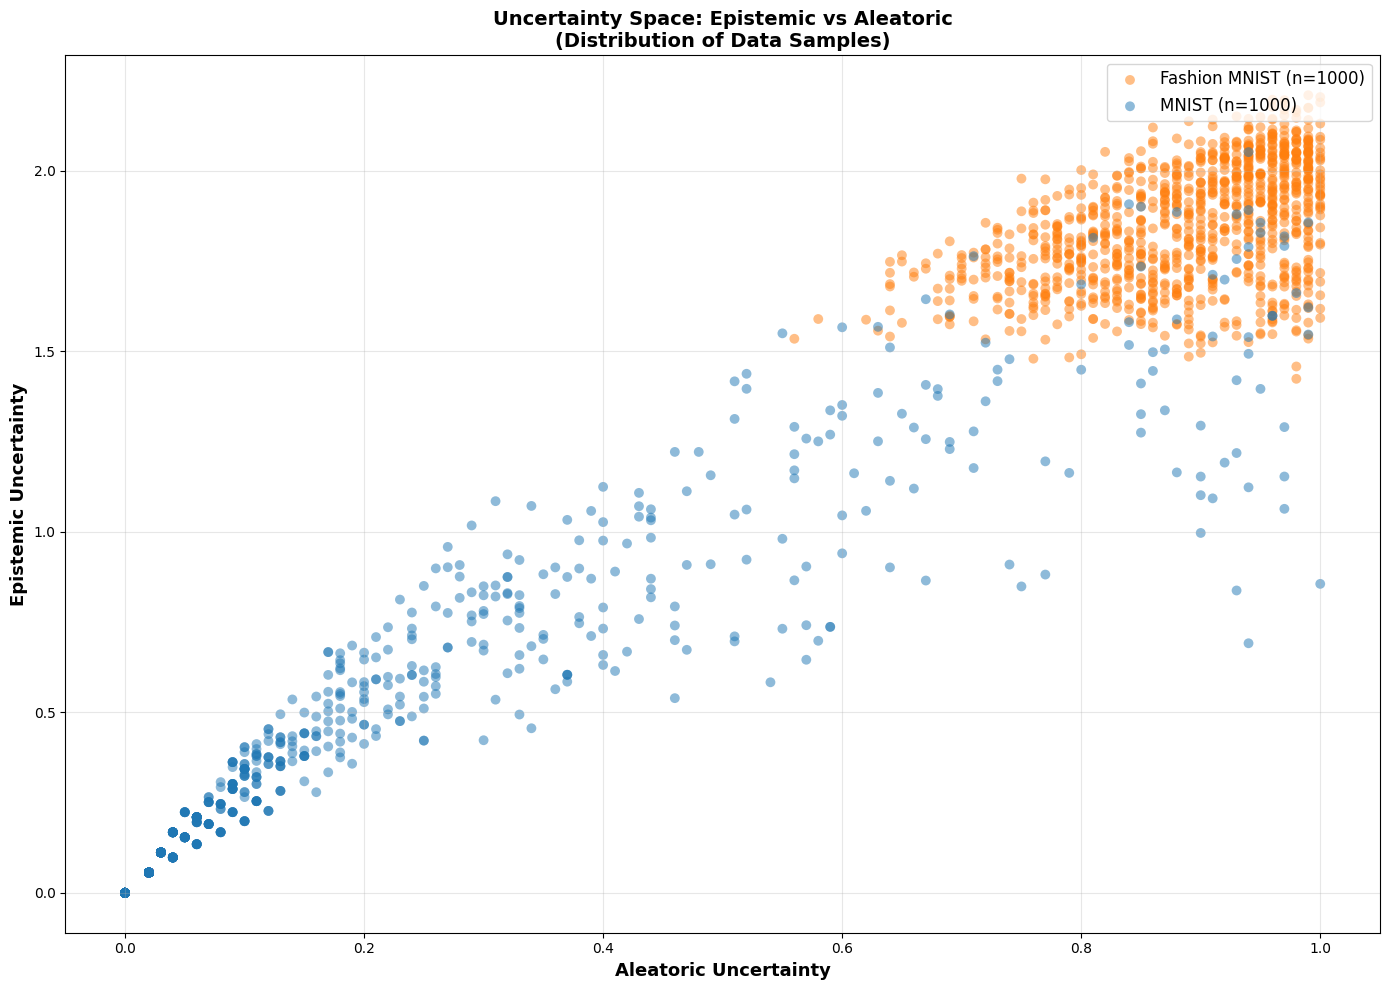


MNIST Sample Statistics:
  Aleatoric - Mean: 0.166460, Std: 0.249450
  Epistemic - Mean: 0.356208, Std: 0.456169

Fashion MNIST Sample Statistics:
  Aleatoric - Mean: 0.885860, Std: 0.087027
  Epistemic - Mean: 1.845844, Std: 0.162394

Center separation distance: 1.654252


In [35]:
# 2D Uncertainty Space: Aleatoric vs Epistemic
print("\n" + "="*70)
print("2D UNCERTAINTY SPACE VISUALIZATION")
print("="*70 + "\n")

# Select 1000 random samples from MNIST test set
mnist_sample_size = min(1000, len(epistemic_mnist))
mnist_indices = np.random.choice(len(epistemic_mnist), mnist_sample_size, replace=False)
epistemic_mnist_sample = epistemic_mnist[mnist_indices]
aleatoric_mnist_sample = aleatoric_mnist[mnist_indices]

# Use up to 1000 Fashion MNIST samples
fmnist_sample_size = min(1000, len(epistemic_fmnist))
epistemic_fmnist_sample = epistemic_fmnist[:fmnist_sample_size]
aleatoric_fmnist_sample = aleatoric_fmnist[:fmnist_sample_size]

print(f"MNIST samples: {mnist_sample_size}")
print(f"Fashion MNIST samples: {fmnist_sample_size}")

# Create 2D scatter plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot Fashion MNIST (red/orange points)
scatter1 = ax.scatter(aleatoric_fmnist_sample, epistemic_fmnist_sample, 
                      alpha=0.5, s=50, color='#ff7f0e', label=f'Fashion MNIST (n={fmnist_sample_size})',
                      edgecolors='none')

# Plot MNIST (blue points)
scatter2 = ax.scatter(aleatoric_mnist_sample, epistemic_mnist_sample, 
                      alpha=0.5, s=50, color='#1f77b4', label=f'MNIST (n={mnist_sample_size})',
                      edgecolors='none')

ax.set_xlabel('Aleatoric Uncertainty', fontsize=13, fontweight='bold')
ax.set_ylabel('Epistemic Uncertainty', fontsize=13, fontweight='bold')
ax.set_title('Uncertainty Space: Epistemic vs Aleatoric\n(Distribution of Data Samples)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for the 2D space
print("\nMNIST Sample Statistics:")
print(f"  Aleatoric - Mean: {aleatoric_mnist_sample.mean():.6f}, Std: {aleatoric_mnist_sample.std():.6f}")
print(f"  Epistemic - Mean: {epistemic_mnist_sample.mean():.6f}, Std: {epistemic_mnist_sample.std():.6f}")

print("\nFashion MNIST Sample Statistics:")
print(f"  Aleatoric - Mean: {aleatoric_fmnist_sample.mean():.6f}, Std: {aleatoric_fmnist_sample.std():.6f}")
print(f"  Epistemic - Mean: {epistemic_fmnist_sample.mean():.6f}, Std: {epistemic_fmnist_sample.std():.6f}")

# Calculate separation in 2D space
mnist_center = np.array([aleatoric_mnist_sample.mean(), epistemic_mnist_sample.mean()])
fmnist_center = np.array([aleatoric_fmnist_sample.mean(), epistemic_fmnist_sample.mean()])
separation_distance = np.linalg.norm(fmnist_center - mnist_center)

print(f"\nCenter separation distance: {separation_distance:.6f}")

In [36]:
# Calculate anomaly threshold based on cumulative uncertainty
print("\n" + "="*70)
print("ANOMALY DETECTION THRESHOLD CALCULATION")
print("="*70 + "\n")

# We want 5% of MNIST samples to be classified as anomalies
# Find the 95th percentile of cumulative uncertainty
anomaly_threshold_percentile = 95
anomaly_threshold = np.percentile(cumulative_uncertainty, anomaly_threshold_percentile)

print(f"Anomaly Detection Configuration:")
print(f"  - Percentile used: {anomaly_threshold_percentile}%")
print(f"  - Cumulative uncertainty threshold: {anomaly_threshold:.6f}")

# Count how many MNIST samples are above the threshold
n_anomalies_mnist = np.sum(cumulative_uncertainty >= anomaly_threshold)
pct_anomalies_mnist = 100 * n_anomalies_mnist / len(cumulative_uncertainty)

print(f"\nMNIST Test Set Results:")
print(f"  - Total samples: {len(cumulative_uncertainty)}")
print(f"  - Samples above threshold: {n_anomalies_mnist}")
print(f"  - Percentage: {pct_anomalies_mnist:.2f}%")

# Apply to Fashion MNIST
n_anomalies_fmnist = np.sum((0.5 * epistemic_fmnist + 0.5 * aleatoric_fmnist) >= anomaly_threshold)
pct_anomalies_fmnist = 100 * n_anomalies_fmnist / len(epistemic_fmnist)

print(f"\nFashion MNIST Results:")
print(f"  - Total samples: {len(epistemic_fmnist)}")
print(f"  - Samples classified as anomalies: {n_anomalies_fmnist}")
print(f"  - Percentage: {pct_anomalies_fmnist:.2f}%")

# Create predictions with anomaly class (10 = anomaly)
y_pred_with_anomaly_mnist = np.copy(y_pred_test_rf).astype(int)
y_pred_with_anomaly_mnist[cumulative_uncertainty >= anomaly_threshold] = 10

y_pred_with_anomaly_fmnist = np.copy(y_pred_fashion_rf).astype(int)
fmnist_cumulative = 0.5 * epistemic_fmnist + 0.5 * aleatoric_fmnist
y_pred_with_anomaly_fmnist[fmnist_cumulative >= anomaly_threshold] = 10

print(f"\nPredictions with anomaly class created (class 10 = anomaly)")
print(f"MNIST with anomaly predictions: {y_pred_with_anomaly_mnist.shape}")
print(f"Fashion MNIST with anomaly predictions: {y_pred_with_anomaly_fmnist.shape}")


ANOMALY DETECTION THRESHOLD CALCULATION

Anomaly Detection Configuration:
  - Percentile used: 95%
  - Cumulative uncertainty threshold: 0.194644

MNIST Test Set Results:
  - Total samples: 10000
  - Samples above threshold: 500
  - Percentage: 5.00%

Fashion MNIST Results:
  - Total samples: 1000
  - Samples classified as anomalies: 1000
  - Percentage: 100.00%

Predictions with anomaly class created (class 10 = anomaly)
MNIST with anomaly predictions: (10000,)
Fashion MNIST with anomaly predictions: (1000,)



ANOMALY DETECTION BOUNDARY VISUALIZATION



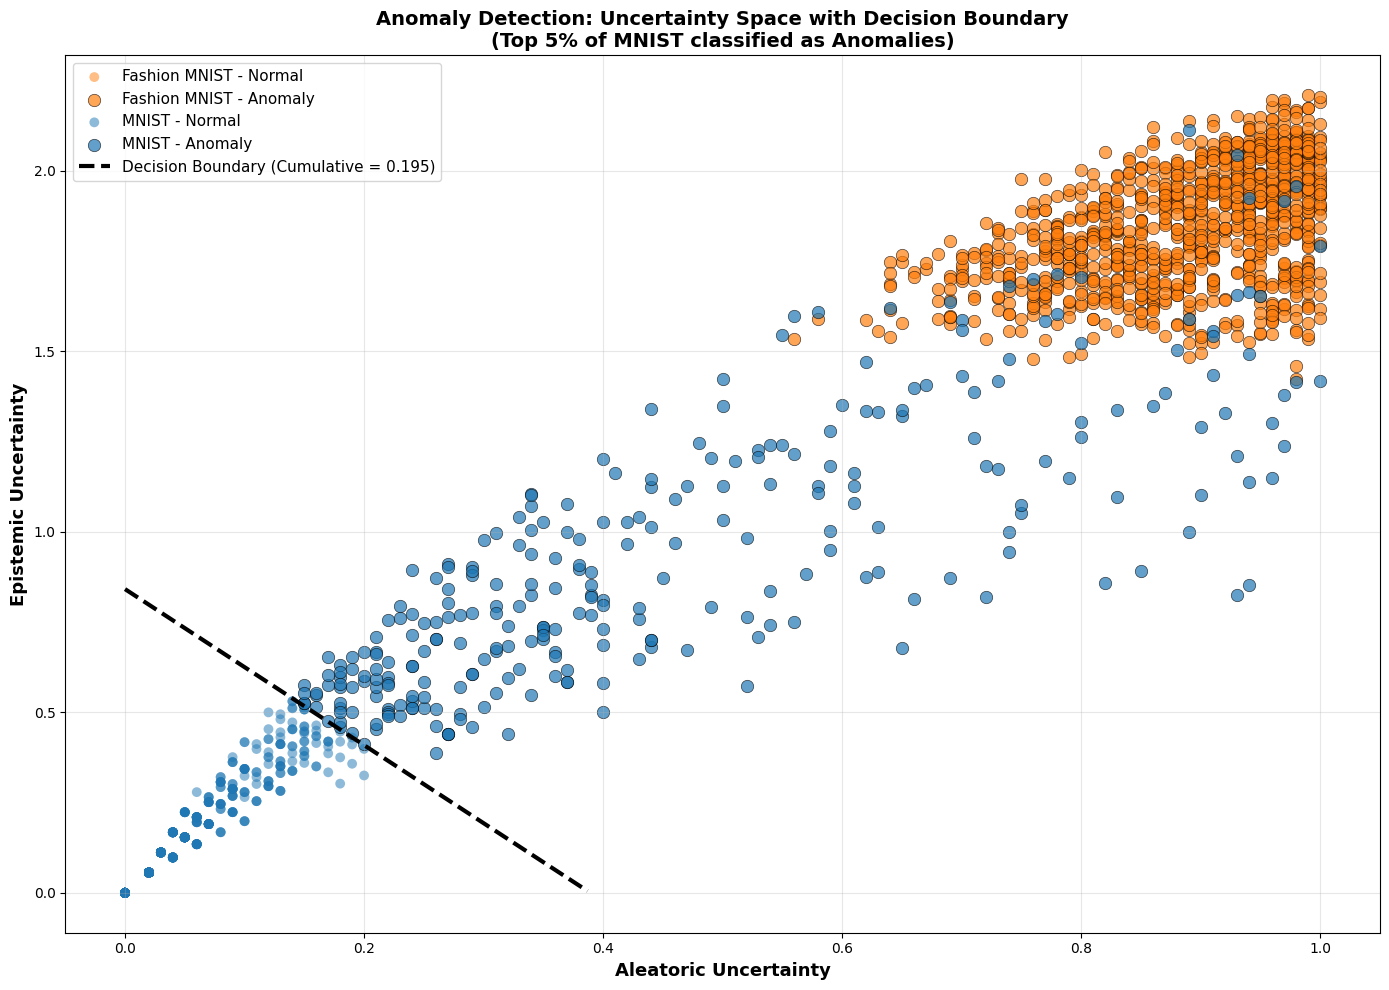

Visualization complete!

Boundary equation: 0.5 * epistemic_norm + 0.5 * aleatoric_norm = 0.194644
Where: epistemic_norm = (epistemic - -0.000) / 2.161
       aleatoric_norm = (aleatoric - 0.000) / 1.000


In [37]:
# Visualize the anomaly detection boundary in 2D space
print("\n" + "="*70)
print("ANOMALY DETECTION BOUNDARY VISUALIZATION")
print("="*70 + "\n")

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data for visualization (same as before)
mnist_sample_size = min(1000, len(epistemic_mnist))
mnist_indices = np.random.choice(len(epistemic_mnist), mnist_sample_size, replace=False)
epistemic_mnist_sample = epistemic_mnist[mnist_indices]
aleatoric_mnist_sample = aleatoric_mnist[mnist_indices]

fmnist_sample_size = min(1000, len(epistemic_fmnist))
epistemic_fmnist_sample = epistemic_fmnist[:fmnist_sample_size]
aleatoric_fmnist_sample = aleatoric_fmnist[:fmnist_sample_size]

# Calculate cumulative uncertainties for boundary
epi_min, epi_max = epistemic_mnist.min(), epistemic_mnist.max()
ale_min, ale_max = aleatoric_mnist.min(), aleatoric_mnist.max()

epistemic_norm_sample_mnist = (epistemic_mnist_sample - epi_min) / (epi_max - epi_min + 1e-10)
aleatoric_norm_sample_mnist = (aleatoric_mnist_sample - ale_min) / (ale_max - ale_min + 1e-10)
cumulative_sample_mnist = 0.5 * epistemic_norm_sample_mnist + 0.5 * aleatoric_norm_sample_mnist

epistemic_norm_sample_fmnist = (epistemic_fmnist_sample - epi_min) / (epi_max - epi_min + 1e-10)
aleatoric_norm_sample_fmnist = (aleatoric_fmnist_sample - ale_min) / (ale_max - ale_min + 1e-10)
cumulative_sample_fmnist = 0.5 * epistemic_norm_sample_fmnist + 0.5 * aleatoric_norm_sample_fmnist

# Normalize threshold to sample space
threshold_norm = (anomaly_threshold - 0) / (1 - 0)

# Plot Fashion MNIST (non-anomaly)
fmnist_mask = cumulative_sample_fmnist < threshold_norm
scatter1 = ax.scatter(aleatoric_fmnist_sample[fmnist_mask], epistemic_fmnist_sample[fmnist_mask], 
                      alpha=0.5, s=50, color='#ff7f0e', label=f'Fashion MNIST - Normal',
                      edgecolors='none')

# Plot Fashion MNIST anomalies
fmnist_anom_mask = cumulative_sample_fmnist >= threshold_norm
scatter2 = ax.scatter(aleatoric_fmnist_sample[fmnist_anom_mask], epistemic_fmnist_sample[fmnist_anom_mask], 
                      alpha=0.7, s=80, color='#ff7f0e', marker='o', label=f'Fashion MNIST - Anomaly',
                      edgecolors='black', linewidth=0.5)

# Plot MNIST (non-anomaly)
mnist_mask = cumulative_sample_mnist < threshold_norm
scatter3 = ax.scatter(aleatoric_mnist_sample[mnist_mask], epistemic_mnist_sample[mnist_mask], 
                      alpha=0.5, s=50, color='#1f77b4', label=f'MNIST - Normal',
                      edgecolors='none')

# Plot MNIST anomalies
mnist_anom_mask = cumulative_sample_mnist >= threshold_norm
scatter4 = ax.scatter(aleatoric_mnist_sample[mnist_anom_mask], epistemic_mnist_sample[mnist_anom_mask], 
                      alpha=0.7, s=80, color='#1f77b4', marker='o', label=f'MNIST - Anomaly',
                      edgecolors='black', linewidth=0.5)

# Draw decision boundary: cumulative = 0.5 * epistemic_norm + 0.5 * aleatoric_norm = threshold
# Rearranged: epistemic = 2 * threshold - aleatoric
ale_range = np.linspace(aleatoric_mnist.min(), aleatoric_mnist.max(), 200)
ale_norm_range = (ale_range - ale_min) / (ale_max - ale_min + 1e-10)
epi_norm_boundary = 2 * threshold_norm - ale_norm_range
epi_boundary = epi_norm_boundary * (epi_max - epi_min) + epi_min

# Only plot valid part of boundary
valid_mask = (epi_boundary >= epistemic_mnist.min()) & (epi_boundary <= epistemic_mnist.max())
ax.plot(ale_range[valid_mask], epi_boundary[valid_mask], 'k--', linewidth=3, 
        label=f'Decision Boundary (Cumulative = {anomaly_threshold:.3f})', zorder=10)

ax.set_xlabel('Aleatoric Uncertainty', fontsize=13, fontweight='bold')
ax.set_ylabel('Epistemic Uncertainty', fontsize=13, fontweight='bold')
ax.set_title('Anomaly Detection: Uncertainty Space with Decision Boundary\n(Top 5% of MNIST classified as Anomalies)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")
print(f"\nBoundary equation: 0.5 * epistemic_norm + 0.5 * aleatoric_norm = {threshold_norm:.6f}")
print(f"Where: epistemic_norm = (epistemic - {epi_min:.3f}) / {epi_max - epi_min:.3f}")
print(f"       aleatoric_norm = (aleatoric - {ale_min:.3f}) / {ale_max - ale_min:.3f}")

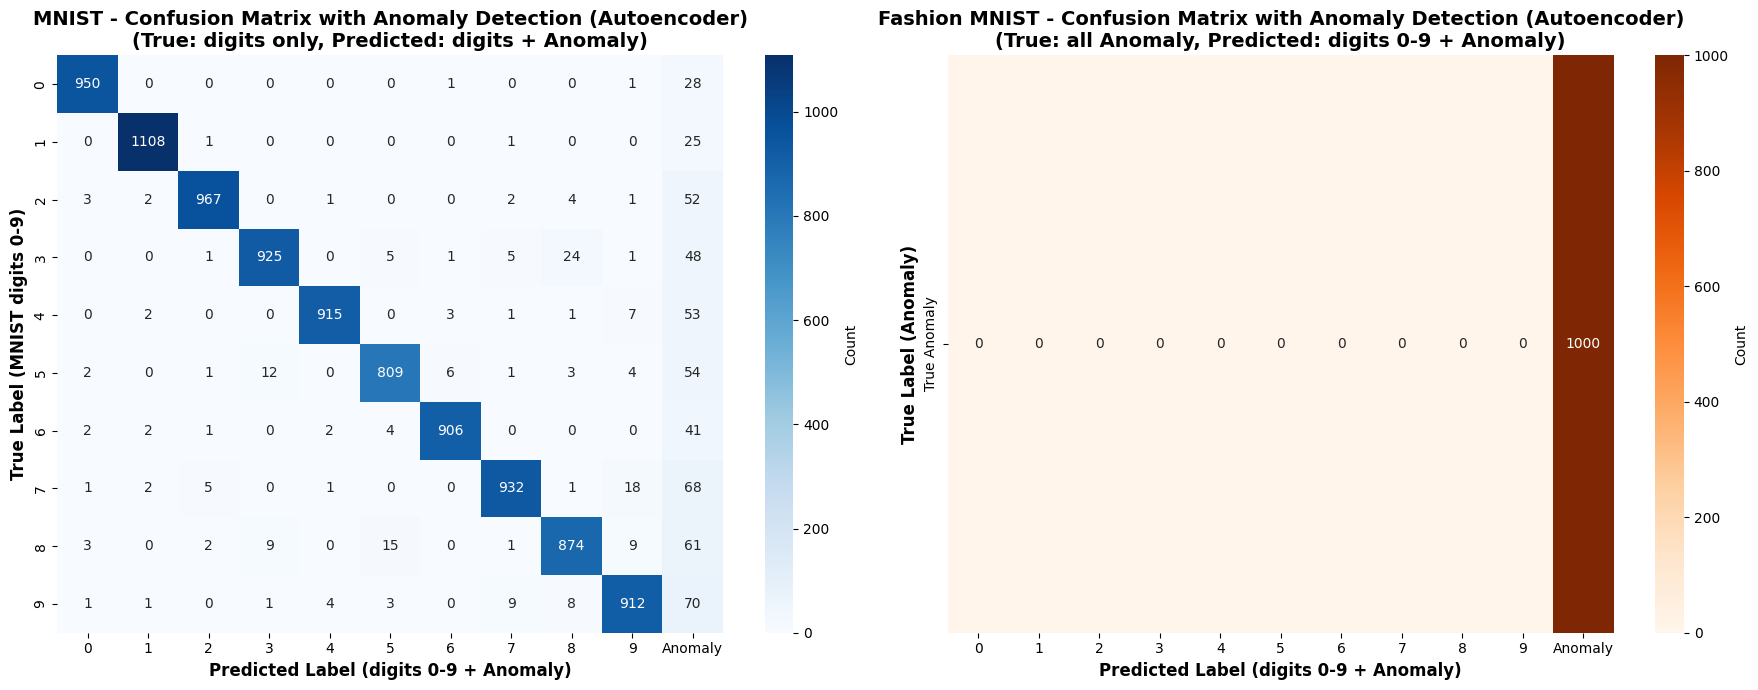

Confusion matrices visualization complete (Autoencoder)!


In [38]:
# Create confusion matrices for Autoencoder section
# MNIST confusion matrix
cm_mnist_full_ae = confusion_matrix(y_test, y_pred_with_anomaly_mnist, labels=range(11))
cm_mnist_anom_ae = cm_mnist_full_ae[:-1, :]  # Extract rows 0-9 (digits only, excluding anomaly row)

# Fashion MNIST confusion matrix  
cm_fmnist_full_ae = confusion_matrix(y_fashion_true_anomaly, y_pred_with_anomaly_fmnist, labels=range(11))
cm_fmnist_anom_ae = cm_fmnist_full_ae[-1:, :]  # Extract row 10 (anomaly row only)

# Visualize confusion matrices as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# MNIST heatmap (10 rows for true digits, 11 columns for predictions)
sns.heatmap(cm_mnist_anom_ae, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_with_anomaly, 
            yticklabels=class_names_digits,
            cbar_kws={'label': 'Count'},
            ax=axes[0])
axes[0].set_title('MNIST - Confusion Matrix with Anomaly Detection (Autoencoder)\n(True: digits only, Predicted: digits + Anomaly)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label (MNIST digits 0-9)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label (digits 0-9 + Anomaly)', fontsize=12, fontweight='bold')

# Fashion MNIST heatmap (1 row for Anomaly true label, 11 columns for predictions)
sns.heatmap(cm_fmnist_anom_ae, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names_with_anomaly,
            yticklabels=['True Anomaly'],
            cbar_kws={'label': 'Count'},
            ax=axes[1])
axes[1].set_title('Fashion MNIST - Confusion Matrix with Anomaly Detection (Autoencoder)\n(True: all Anomaly, Predicted: digits 0-9 + Anomaly)', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label (Anomaly)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label (digits 0-9 + Anomaly)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Confusion matrices visualization complete (Autoencoder)!")